# ***0. Setup***

In [1]:
from __future__ import annotations

import os

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"

import math
import random
import time
import tracemalloc
from collections import defaultdict
from collections.abc import Callable, Mapping, Sequence
from dataclasses import dataclass
from functools import partial
from pathlib import Path
from typing import Literal, Protocol, Self, TypeVar

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from cycler import cycler
from matplotlib_inline.backend_inline import set_matplotlib_formats
from torch import nn
from torch.utils.data import DataLoader
from tqdm import tqdm

T = TypeVar("T")
CellType = Literal["rnn", "lstm"]

In [2]:
SEED = 42
DEVICE_ID = 7
DATA_SUBDIR = Path("data") / "problem1"
FIGURE_SUBDIR = Path("outputs") / "figures" / "hw1_1"
TRAIN_FILE = "train.csv"
SPLIT_NAMES = ("train", "val", "test")
LANGUAGES = ("English", "French", "Spanish", "Portuguese", "German")
LANGUAGE_CODES = {"English": "EN", "French": "FR", "Spanish": "ES", "Portuguese": "PT", "German": "DE"}
MODEL_NAMES = ("Bigram", "Trigram", "RNN", "LSTM")
PAD, UNK, BOS, EOS = "<PAD>", "<UNK>", "<BOS>", "<EOS>"
LENGTH_BINS = (0, 30, 60, 120, np.inf)
LENGTH_LABELS = ("<=30", "31-60", "61-120", ">120")
BYTES_PER_MB = 2**20
EPSILON = 1e-12
ERROR_EXAMPLES = 10
CORRECT_EXAMPLES = 5
TOP_CONFUSED_PAIRS = 5

ACADEMIC_PALETTE = ("#4C72B0", "#55A868", "#DD8452", "#C44E52", "#8172B3", "#937860")
ACADEMIC_MARKERS = ("o", "s", "^", "D", "v", "P")
FIGURE_DPI = 300
DISPLAY_DPI = 150
FIGURE_SUFFIXES = (".pdf", ".png")
PANEL_SIZE = (4.6, 3.8)
PANEL_LABELS = "abcdefgh"
LANGUAGE_STYLES = {
    language: {"color": color, "marker": marker}
    for language, color, marker in zip(LANGUAGES, ACADEMIC_PALETTE, ACADEMIC_MARKERS)
}
MODEL_STYLES = {
    model: {"color": color, "marker": marker}
    for model, color, marker in zip(MODEL_NAMES, ACADEMIC_PALETTE, ACADEMIC_MARKERS)
}


def locate_data(*, start: Path) -> tuple[Path, Path]:
    for directory in (start, *start.parents):
        for candidate in (directory / DATA_SUBDIR, directory):
            if (candidate / TRAIN_FILE).is_file():
                return directory, candidate
    raise FileNotFoundError(f"{TRAIN_FILE} not found above {start}")


def set_seed(*, seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def select_device(*, device_id: int) -> torch.device:
    if not torch.cuda.is_available():
        return torch.device("cpu")
    return torch.device(f"cuda:{device_id}" if device_id < torch.cuda.device_count() else "cuda")


def apply_academic_style() -> None:
    plt.rcParams.update(
        {
            "font.family": "serif",
            "mathtext.fontset": "dejavuserif",
            "font.size": 11,
            "axes.labelsize": 11,
            "axes.titlesize": 12,
            "legend.fontsize": 10,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "axes.grid": True,
            "grid.color": "#E5E5E5",
            "grid.linewidth": 0.6,
            "axes.prop_cycle": cycler(
                color=ACADEMIC_PALETTE,
                marker=ACADEMIC_MARKERS,
            ),
            "lines.linewidth": 1.8,
            "lines.markersize": 6,
            "legend.frameon": False,
            "figure.dpi": DISPLAY_DPI,
            "savefig.dpi": FIGURE_DPI,
            "savefig.bbox": "tight",
        }
    )


def save_figure(
    *,
    figure: plt.Figure,
    path: Path,
) -> None:
    path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )
    for suffix in FIGURE_SUFFIXES:
        figure.savefig(path.with_suffix(suffix))


def panel_title(
    *,
    index: int,
    title: str,
) -> str:
    return f"({PANEL_LABELS[index]}) {title}"


PROJECT_ROOT, DATA_DIR = locate_data(start=Path.cwd().resolve())
FIGURE_DIR = PROJECT_ROOT / FIGURE_SUBDIR

set_seed(seed=SEED)
set_matplotlib_formats("retina")
apply_academic_style()
device = select_device(device_id=DEVICE_ID)
print("Device:", device, torch.cuda.get_device_name(device=device) if device.type == "cuda" else "")
print("Data directory:", DATA_DIR)

Device: cuda:7 NVIDIA RTX A5000
Data directory: /home/longpm/works/knowledge/llm-nycu/hw1/data/problem1


## ***0.1 Data***

In [3]:
def load_split(
    *,
    data_dir: Path,
    name: str,
) -> pd.DataFrame:
    return pd.read_csv(filepath_or_buffer=data_dir / f"{name}.csv")


train_df, val_df, test_df = (
    load_split(
        data_dir=DATA_DIR,
        name=name,
    )
    for name in SPLIT_NAMES
)

for name, frame in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    print(name, frame.shape, frame["Language"].value_counts().reindex(index=LANGUAGES).tolist())
display(train_df.head())
display(train_df["Text"].str.len().describe().to_frame(name="train text length"))

Train (5600, 2) [1120, 1120, 1120, 1120, 1120]
Validation (700, 2) [140, 140, 140, 140, 140]
Test (700, 2) [140, 140, 140, 140, 140]


,Text,Language
0,"Also dachte ich, es wäre interessant, ein Gerü...",German
1,"C'est faux, complètement faux.",French
2,"Para mim, como para milhões de outras pessoas",Portuguese
3,"produciendo químicos volátiles,",Spanish
4,Esta es la estructura completa del avión.,Spanish


,train text length
count,5600.000000
mean,63.396786
std,79.004161
min,4.000000
25%,28.000000
50%,40.000000
75%,59.000000
max,1334.000000


## ***0.2 Shared Character Vocabulary***

In [4]:
@dataclass(
    frozen=True,
    slots=True,
)
class Vocabulary:
    token_to_id: Mapping[str, int]

    @property
    def size(self) -> int:
        return len(self.token_to_id)

    @property
    def pad_id(self) -> int:
        return self.token_to_id[PAD]

    @property
    def unk_id(self) -> int:
        return self.token_to_id[UNK]

    @property
    def bos_id(self) -> int:
        return self.token_to_id[BOS]

    @property
    def eos_id(self) -> int:
        return self.token_to_id[EOS]

    def encode(self, *, text: str) -> list[int]:
        return [self.token_to_id.get(character, self.unk_id) for character in text]


@dataclass(
    frozen=True,
    slots=True,
)
class Split:
    frame: pd.DataFrame
    sequences: tuple[list[int], ...]
    by_language: Mapping[str, tuple[list[int], ...]]


def build_vocabulary(*, texts: Sequence[str]) -> Vocabulary:
    tokens = [PAD, UNK, BOS, EOS, *sorted(set("".join(texts)))]
    return Vocabulary(token_to_id={token: index for index, token in enumerate(tokens)})


def build_split(
    *,
    frame: pd.DataFrame,
    vocabulary: Vocabulary,
) -> Split:
    sequences = tuple(vocabulary.encode(text=text) for text in frame["Text"])
    languages = frame["Language"].tolist()
    by_language = {
        language: tuple(ids for ids, label in zip(sequences, languages) if label == language) for language in LANGUAGES
    }
    return Split(
        frame=frame,
        sequences=sequences,
        by_language=by_language,
    )


vocabulary = build_vocabulary(texts=train_df["Text"].tolist())
train_split, val_split, test_split = (
    build_split(
        frame=frame,
        vocabulary=vocabulary,
    )
    for frame in (train_df, val_df, test_df)
)

print("Vocabulary size |V|:", vocabulary.size)
print("Test <UNK> rate:", np.mean([token == vocabulary.unk_id for ids in test_split.sequences for token in ids]))

Vocabulary size |V|: 129
Test <UNK> rate: 0.0


## ***0.3 Evaluation Utilities***

In [5]:
@dataclass(
    frozen=True,
    slots=True,
)
class Cost:
    seconds: float
    peak_mb: float


@dataclass(
    frozen=True,
    slots=True,
)
class Evaluation:
    accuracy: float
    macro_f1: float
    corpus_ppl: float
    confusion: np.ndarray
    table: pd.DataFrame


class LanguageModel(Protocol):
    def sequence_nll(self, *, sequences: Sequence[list[int]]) -> np.ndarray: ...


def score(
    *,
    models: Mapping[str, LanguageModel],
    split: Split,
) -> tuple[np.ndarray, np.ndarray]:
    nll = np.stack(
        arrays=[models[language].sequence_nll(sequences=split.sequences) for language in LANGUAGES],
        axis=1,
    )
    return nll, np.array(
        [len(ids) + 1 for ids in split.sequences],
        dtype=float,
    )


def confusion_matrix(
    *,
    y_true: Sequence[str],
    y_pred: Sequence[str],
) -> np.ndarray:
    matrix = np.zeros(
        shape=(len(LANGUAGES), len(LANGUAGES)),
        dtype=int,
    )
    for true_language, pred_language in zip(y_true, y_pred):
        matrix[LANGUAGES.index(true_language), LANGUAGES.index(pred_language)] += 1
    return matrix


def macro_f1(*, matrix: np.ndarray) -> float:
    hits = np.diag(matrix).astype(float)
    precision = hits / np.maximum(matrix.sum(axis=0), 1)
    recall = hits / np.maximum(matrix.sum(axis=1), 1)
    return float(np.mean(2 * precision * recall / np.maximum(precision + recall, EPSILON)))


def build_prediction_table(
    *,
    nll: np.ndarray,
    lengths: np.ndarray,
    frame: pd.DataFrame,
) -> pd.DataFrame:
    perplexity = np.exp(nll / lengths[:, None])
    table = frame[["Text", "Language"]].assign(
        Predicted=[LANGUAGES[index] for index in perplexity.argmin(axis=1)],
        Length=frame["Text"].str.len(),
        **{f"PPL_{language}": perplexity[:, index] for index, language in enumerate(LANGUAGES)},
    )
    table["Correct"] = table["Language"] == table["Predicted"]
    return table


def evaluate(
    *,
    nll: np.ndarray,
    lengths: np.ndarray,
    frame: pd.DataFrame,
) -> Evaluation:
    table = build_prediction_table(
        nll=nll,
        lengths=lengths,
        frame=frame,
    )
    true_columns = np.array([LANGUAGES.index(language) for language in frame["Language"]])
    matrix = confusion_matrix(
        y_true=table["Language"],
        y_pred=table["Predicted"],
    )
    return Evaluation(
        accuracy=float(table["Correct"].mean()),
        macro_f1=macro_f1(matrix=matrix),
        corpus_ppl=math.exp(nll[np.arange(len(frame)), true_columns].sum() / lengths.sum()),
        confusion=matrix,
        table=table,
    )


def evaluate_split(
    *,
    models: Mapping[str, LanguageModel],
    split: Split,
) -> Evaluation:
    nll, lengths = score(
        models=models,
        split=split,
    )
    return evaluate(
        nll=nll,
        lengths=lengths,
        frame=split.frame,
    )


def summarize(*, evaluations: Mapping[str, Evaluation]) -> pd.DataFrame:
    rows = {
        name: {"accuracy": evaluation.accuracy, "macro_f1": evaluation.macro_f1, "corpus_ppl": evaluation.corpus_ppl}
        for name, evaluation in evaluations.items()
    }
    return pd.DataFrame(data=rows).T


def accuracy_by_length(*, table: pd.DataFrame) -> pd.DataFrame:
    buckets = pd.cut(
        x=table["Length"],
        bins=LENGTH_BINS,
        labels=LENGTH_LABELS,
    )
    return table.groupby(
        by=buckets,
        observed=False,
    )["Correct"].agg(
        accuracy="mean",
        count="count",
    )


def confused_pairs(*, matrix: np.ndarray) -> pd.DataFrame:
    errors = matrix - np.diag(np.diag(matrix))
    pairs = {
        f"{LANGUAGES[i]} <-> {LANGUAGES[j]}": errors[i, j] + errors[j, i]
        for i in range(len(LANGUAGES))
        for j in range(i + 1, len(LANGUAGES))
    }
    return (
        pd.Series(
            data=pairs,
            name="errors",
        )
        .sort_values(ascending=False)
        .to_frame()
    )


def plot_confusion_matrices(
    *,
    matrices: Mapping[str, np.ndarray],
    path: Path,
) -> None:
    width, height = PANEL_SIZE
    figure, axes = plt.subplots(
        nrows=1,
        ncols=len(matrices),
        figsize=(width * len(matrices), height),
        squeeze=False,
        constrained_layout=True,
    )
    codes = [LANGUAGE_CODES[language] for language in LANGUAGES]
    for index, (ax, (title, matrix)) in enumerate(zip(axes[0], matrices.items())):
        normalized = matrix / np.maximum(
            matrix.sum(
                axis=1,
                keepdims=True,
            ),
            1,
        )
        image = ax.imshow(
            X=normalized,
            cmap="Blues",
            vmin=0.0,
            vmax=1.0,
        )
        ax.set_xticks(
            ticks=range(len(LANGUAGES)),
            labels=codes,
        )
        ax.set_yticks(
            ticks=range(len(LANGUAGES)),
            labels=codes,
        )
        ax.set(
            xlabel="Predicted language",
            ylabel="True language",
            title=panel_title(
                index=index,
                title=title,
            ),
        )
        ax.grid(visible=False)
        for (row, column), value in np.ndenumerate(normalized):
            colour = "white" if value > 0.5 else "black"
            ax.text(
                x=column,
                y=row,
                s=f"{value:.2f}",
                ha="center",
                va="center",
                color=colour,
                fontsize=9,
            )
    figure.colorbar(
        mappable=image,
        ax=axes[0].tolist(),
        shrink=0.85,
        label="Fraction of true language",
    )
    save_figure(
        figure=figure,
        path=path,
    )
    plt.show()


def show_errors(
    *,
    evaluation: Evaluation,
    correct_examples: int = 0,
) -> None:
    table = evaluation.table
    display(confused_pairs(matrix=evaluation.confusion).head(n=TOP_CONFUSED_PAIRS))
    display(accuracy_by_length(table=table))
    if correct_examples:
        display(
            table.loc[table["Correct"]].sample(
                n=correct_examples,
                random_state=SEED,
            )
        )
    display(table.loc[~table["Correct"]].sort_values(by="Length").head(n=ERROR_EXAMPLES))


def measure_cpu(*, task: Callable[[], T]) -> tuple[T, Cost]:
    tracemalloc.start()
    start = time.perf_counter()
    output = task()
    seconds = time.perf_counter() - start
    peak = tracemalloc.get_traced_memory()[1]
    tracemalloc.stop()
    return output, Cost(
        seconds=seconds,
        peak_mb=peak / BYTES_PER_MB,
    )


def measure_gpu(
    *,
    task: Callable[[], T],
    device: torch.device,
) -> tuple[T, Cost]:
    on_cuda = device.type == "cuda"
    if on_cuda:
        torch.cuda.reset_peak_memory_stats(device=device)
        torch.cuda.synchronize(device=device)
    start = time.perf_counter()
    output = task()
    if on_cuda:
        torch.cuda.synchronize(device=device)
    peak = torch.cuda.max_memory_allocated(device=device) / BYTES_PER_MB if on_cuda else float("nan")
    return output, Cost(
        seconds=time.perf_counter() - start,
        peak_mb=peak,
    )

# ***1. N-Gram Language Models***

In [6]:
ALPHA = 1.0
NGRAM_ORDERS = {"Bigram": 2, "Trigram": 3}


class NGramLanguageModel:
    def __init__(
        self,
        *,
        n: int,
        vocabulary: Vocabulary,
        alpha: float = ALPHA,
    ) -> None:
        if n < 1:
            raise ValueError(f"n must be at least 1, got {n}")
        self.n = n
        self.vocabulary = vocabulary
        self.alpha = alpha
        self.ngram_counts: defaultdict[tuple[int, ...], int] = defaultdict(int)
        self.context_counts: defaultdict[tuple[int, ...], int] = defaultdict(int)

    @property
    def stored_counts(self) -> int:
        return len(self.ngram_counts) + len(self.context_counts)

    def _ngrams(self, *, ids: list[int]) -> list[tuple[tuple[int, ...], int]]:
        padded = [self.vocabulary.bos_id] * (self.n - 1) + ids + [self.vocabulary.eos_id]
        return [(tuple(padded[t - self.n + 1 : t]), padded[t]) for t in range(self.n - 1, len(padded))]

    def fit(self, *, sequences: Sequence[list[int]]) -> Self:
        for ids in sequences:
            for context, token in self._ngrams(ids=ids):
                self.context_counts[context] += 1
                self.ngram_counts[context + (token,)] += 1
        return self

    def _log_prob(
        self,
        *,
        context: tuple[int, ...],
        token: int,
    ) -> float:
        numerator = self.ngram_counts.get(context + (token,), 0) + self.alpha
        denominator = self.context_counts.get(context, 0) + self.alpha * self.vocabulary.size
        return math.log(numerator / denominator)

    def sequence_nll(self, *, sequences: Sequence[list[int]]) -> np.ndarray:
        return np.array(
            [
                -sum(
                    self._log_prob(
                        context=context,
                        token=token,
                    )
                    for context, token in self._ngrams(ids=ids)
                )
                for ids in sequences
            ]
        )


def train_ngram_models(
    *,
    n: int,
    split: Split,
    vocabulary: Vocabulary,
) -> dict[str, NGramLanguageModel]:
    return {
        language: NGramLanguageModel(
            n=n,
            vocabulary=vocabulary,
        ).fit(sequences=split.by_language[language])
        for language in LANGUAGES
    }

## ***1(a) Build Bigram and Trigram Models and Evaluate Validation Perplexity***

In [7]:
ngram_models, build_costs = {}, {}
for name, n in NGRAM_ORDERS.items():
    ngram_models[name], build_costs[name] = measure_cpu(
        task=partial(
            train_ngram_models,
            n=n,
            split=train_split,
            vocabulary=vocabulary,
        ),
    )

ngram_val = {
    name: evaluate_split(
        models=models,
        split=val_split,
    )
    for name, models in ngram_models.items()
}
display(summarize(evaluations=ngram_val))

,accuracy,macro_f1,corpus_ppl
Bigram,0.967143,0.967127,11.437324
Trigram,0.992857,0.992872,9.700802


## ***1(b) Test Evaluation: Accuracy, Macro-F1, Corpus Perplexity, Confusion Matrix***

,accuracy,macro_f1,corpus_ppl
Bigram,0.972857,0.972714,11.326449
Trigram,0.987143,0.987075,9.402167


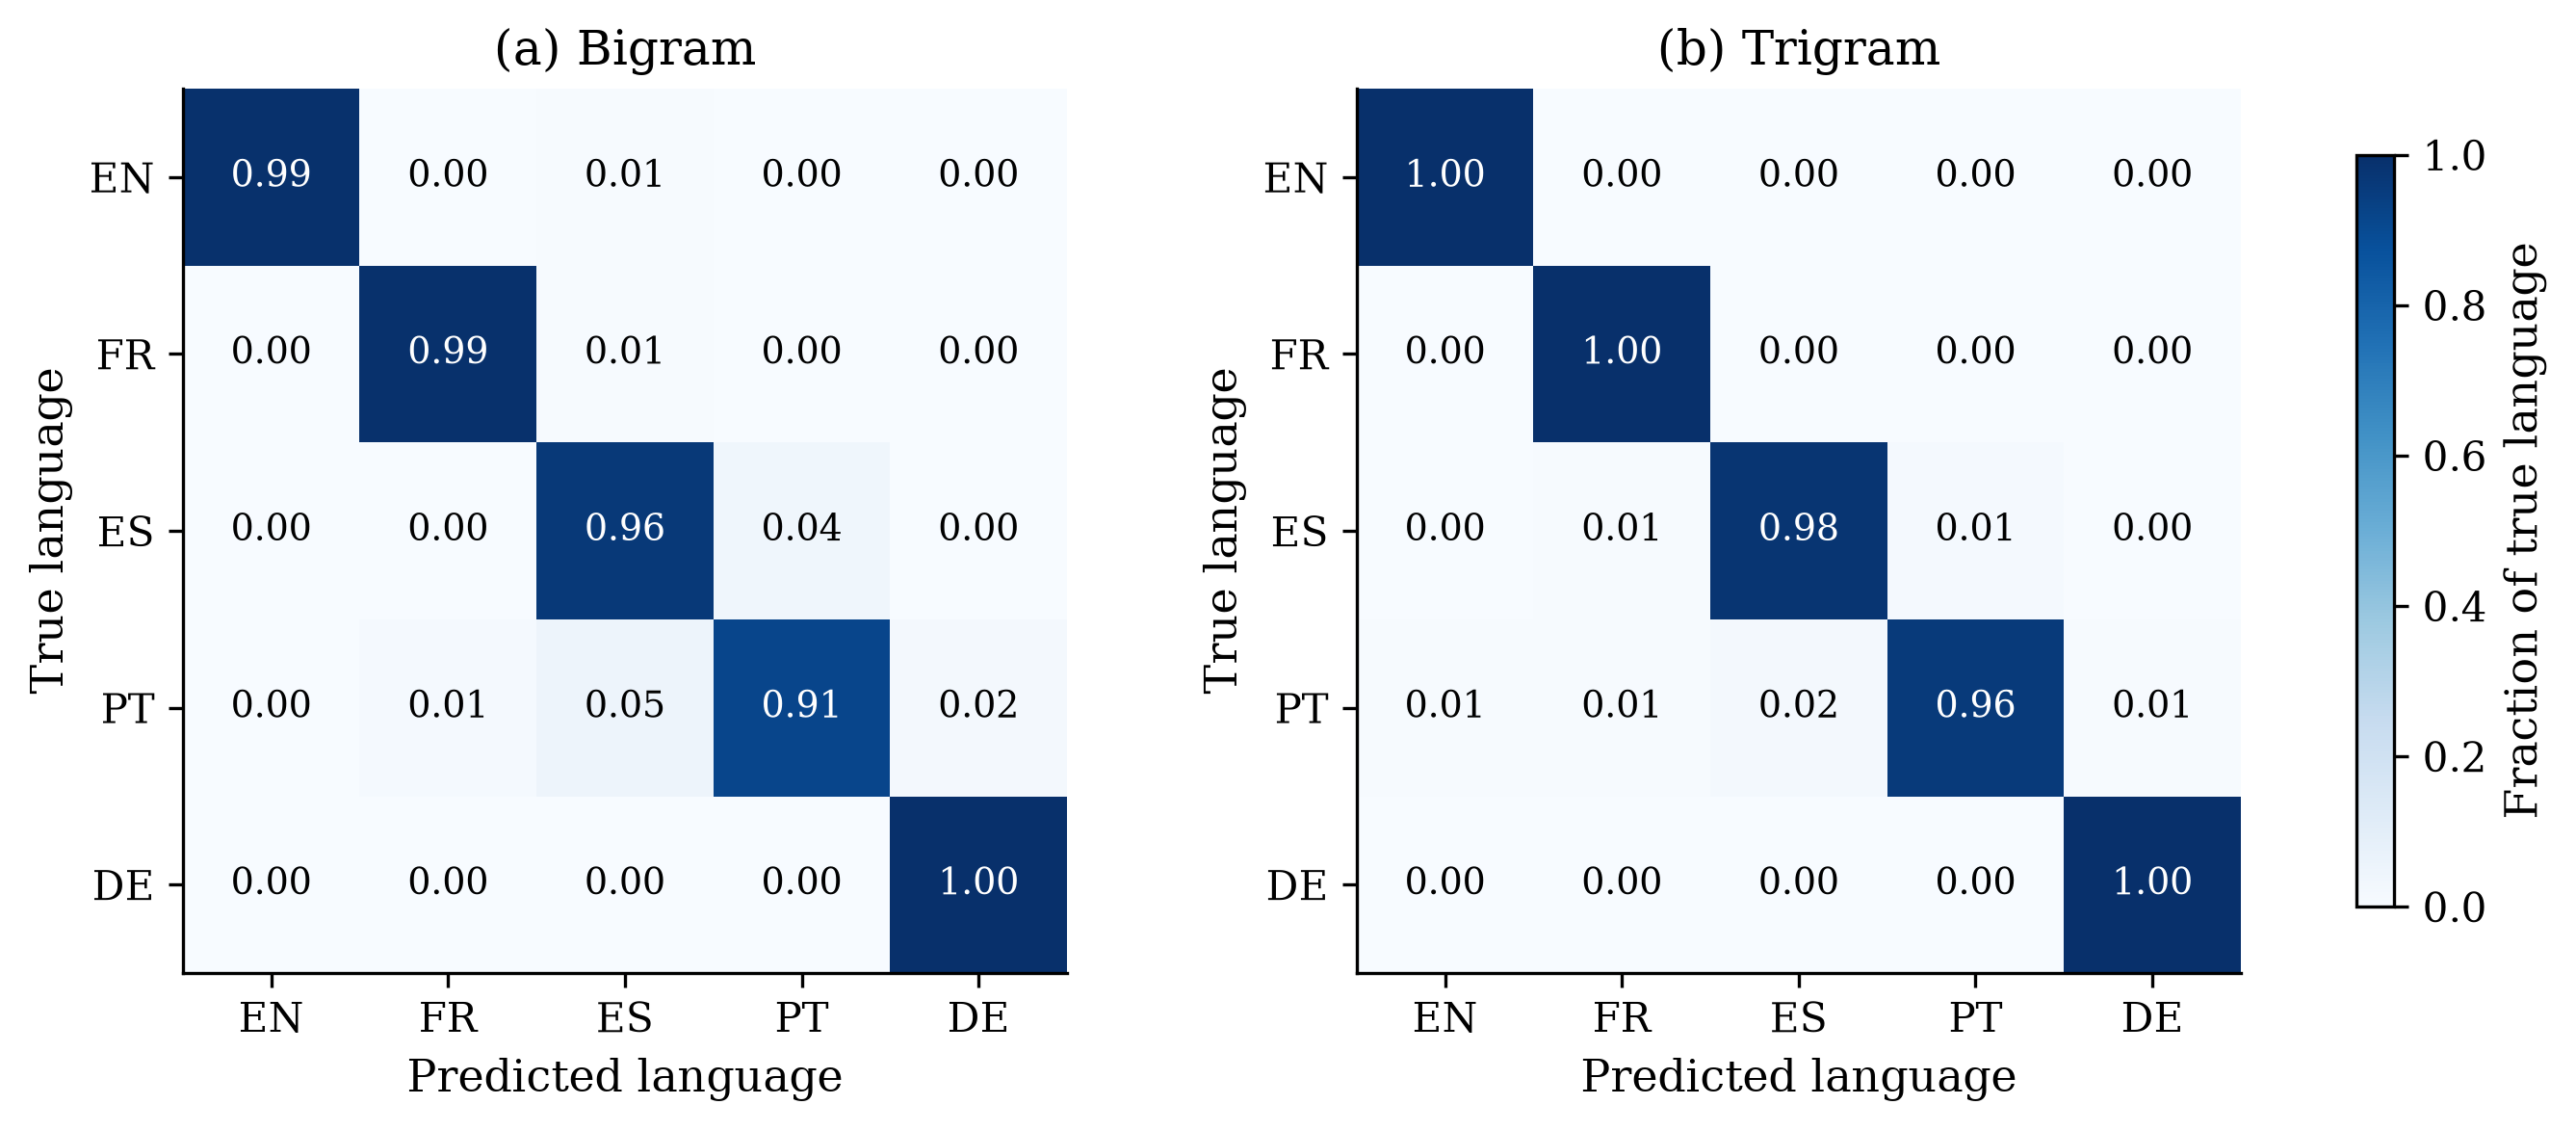

In [8]:
ngram_test, infer_costs = {}, {}
for name, models in ngram_models.items():
    (nll, lengths), infer_costs[name] = measure_cpu(
        task=partial(
            score,
            models=models,
            split=test_split,
        )
    )
    ngram_test[name] = evaluate(
        nll=nll,
        lengths=lengths,
        frame=test_split.frame,
    )

display(summarize(evaluations=ngram_test))
plot_confusion_matrices(
    matrices={name: evaluation.confusion for name, evaluation in ngram_test.items()},
    path=FIGURE_DIR / "ngram_confusion_matrices",
)

## ***1(c) Cost and Error Analysis***

In [9]:
display(
    pd.DataFrame(
        data={
            name: {
                "construction time (s)": build_costs[name].seconds,
                "construction peak memory (MB)": build_costs[name].peak_mb,
                "inference time (s)": infer_costs[name].seconds,
                "inference peak memory (MB)": infer_costs[name].peak_mb,
            }
            for name in ngram_models
        }
    ).T
)

for name, evaluation in ngram_test.items():
    print(f"===== {name} =====")
    show_errors(evaluation=evaluation)

,construction time (s),construction peak memory (MB),inference time (s),inference peak memory (MB)
Bigram,1.055965,0.468047,0.806123,0.058480
Trigram,0.942103,2.852859,0.780470,0.071037


===== Bigram =====


,errors
Spanish <-> Portuguese,12
Portuguese <-> German,3
French <-> Portuguese,2
English <-> Spanish,1
French <-> Spanish,1


,accuracy,count
Length,,
<=30,0.941463,205
31-60,0.981191,319
61-120,0.988889,90
>120,1.000000,86


,Text,Language,Predicted,Length,PPL_English,PPL_French,PPL_Spanish,PPL_Portuguese,PPL_German,Correct
214,4.800 --,Portuguese,German,8,122.792049,75.498153,74.900307,79.654029,66.010690,False
467,"Decidimos,",Portuguese,Spanish,10,27.095916,22.535704,11.715101,12.917730,36.785389,False
605,to protect us,English,Spanish,13,21.355666,23.463775,19.916346,24.239512,42.974988,False
292,para seis graus.,Portuguese,French,16,18.830053,11.830710,15.527183,12.249872,18.432658,False
676,"Ándale! Ándale!""",Portuguese,German,16,81.246577,83.020322,67.614080,65.488466,63.548383,False
435,"un monde de murs,",French,Spanish,17,15.935803,9.321549,8.835153,14.525642,10.129436,False
72,o ritmo cardíaco sobe.,Portuguese,Spanish,22,28.838253,41.851539,17.104287,18.118242,51.721108,False
180,"porque isto, esta rede",Portuguese,Spanish,22,25.884449,17.813339,9.963899,10.242103,31.201351,False
225,era agradar a su padre.,Spanish,Portuguese,23,20.850174,14.220564,12.540997,11.520799,24.105530,False
516,A cobertura jornalística,Portuguese,Spanish,24,38.574786,31.343036,18.554172,18.643109,50.717946,False


===== Trigram =====


,errors
Spanish <-> Portuguese,5
English <-> Portuguese,1
Portuguese <-> German,1
French <-> Spanish,1
French <-> Portuguese,1


,accuracy,count
Length,,
<=30,0.970732,205
31-60,0.990596,319
61-120,1.000000,90
>120,1.000000,86


,Text,Language,Predicted,Length,PPL_English,PPL_French,PPL_Spanish,PPL_Portuguese,PPL_German,Correct
214,4.800 --,Portuguese,German,8,120.486302,79.180644,80.753384,80.701424,77.702294,False
467,"Decidimos,",Portuguese,Spanish,10,56.377575,52.392112,18.856449,20.270822,58.570866,False
676,"Ándale! Ándale!""",Portuguese,Spanish,16,118.795565,110.517446,106.070998,129.099980,156.302457,False
72,o ritmo cardíaco sobe.,Portuguese,Spanish,22,53.135133,59.701881,30.497261,30.567046,76.124565,False
24,"""La tempestad"" en cine.",Spanish,French,23,52.330940,25.546547,25.848889,33.117649,59.502561,False
651,sobre países competitivos.,Spanish,Portuguese,26,28.385132,25.470838,14.570631,14.484493,64.137751,False
386,grupos de gente feliz e infeliz,Spanish,Portuguese,31,35.319312,45.555240,27.030448,17.968192,41.442515,False
147,de correr descalça em Table Mountain e,Portuguese,French,38,30.120953,29.014739,32.921417,33.170483,40.603626,False
485,"Afinal, Jimmy Stewart obstruiu durante",Portuguese,English,38,39.722557,48.680602,42.421666,49.054459,48.439801,False


**Discussion for 1(c)**

Both n-gram models are cheap: they are built on the CPU in about one second, need less than 3 MB of memory and score the test set in about 0.8 s. The trigram is clearly better than the bigram (accuracy 0.987 against 0.973, perplexity 9.40 against 11.33) because two characters of context capture patterns such as "ção" or "sch". Spanish and Portuguese cause most of the errors (12 of 19 for the bigram and 5 of 9 for the trigram), since short fragments like "Decidimos," are valid in both. Short texts are harder: on texts of at most 30 characters the accuracy is 0.941 for the bigram and 0.971 for the trigram, while both are perfect above 120 characters.


# ***2. RNN***

In [10]:
TRAIN_BAR = "{desc} |{bar}| {percentage:3.0f}% {n_fmt}/{total_fmt} [{elapsed}<{remaining}{postfix}]"
CELL_COLOURS: dict[CellType, str] = {"rnn": "cyan", "lstm": "magenta"}
LSTM_GATES = 4


@dataclass(
    frozen=True,
    slots=True,
)
class TrainingSettings:
    embedding_dim: int = 128
    hidden_dim: int = 128
    num_layers: int = 2
    learning_rate: float = 1e-3
    epochs: int = 40
    batch_size: int = 32
    grad_clip: float = 1.0
    eval_batch_size: int = 128


@dataclass(
    frozen=True,
    slots=True,
)
class TrainingHistory:
    train_loss: tuple[float, ...]
    val_ppl: tuple[float, ...]

    @property
    def best_epoch(self) -> int:
        return int(np.argmin(self.val_ppl)) + 1

    @property
    def best_val_ppl(self) -> float:
        return min(self.val_ppl)


SETTINGS = TrainingSettings()


class RNN(nn.Module):
    def __init__(
        self,
        *,
        input_size: int,
        hidden_size: int,
    ) -> None:
        super().__init__()
        self.hidden_size = hidden_size
        self.input_to_hidden = nn.Linear(
            in_features=input_size,
            out_features=hidden_size,
        )
        self.hidden_to_hidden = nn.Linear(
            in_features=hidden_size,
            out_features=hidden_size,
        )

    def initial_state(
        self,
        *,
        batch_size: int,
        device: torch.device,
    ) -> tuple[torch.Tensor, ...]:
        return (
            torch.zeros(
                batch_size,
                self.hidden_size,
                device=device,
            ),
        )

    def step(
        self,
        *,
        projected_input: torch.Tensor,
        state: tuple[torch.Tensor, ...],
    ) -> tuple[torch.Tensor, tuple[torch.Tensor, ...]]:
        hidden = torch.tanh(projected_input + self.hidden_to_hidden(state[0]))
        return hidden, (hidden,)


class LSTM(nn.Module):
    def __init__(
        self,
        *,
        input_size: int,
        hidden_size: int,
    ) -> None:
        super().__init__()
        self.hidden_size = hidden_size
        self.input_to_hidden = nn.Linear(
            in_features=input_size,
            out_features=LSTM_GATES * hidden_size,
        )
        self.hidden_to_hidden = nn.Linear(
            in_features=hidden_size,
            out_features=LSTM_GATES * hidden_size,
        )

    def initial_state(
        self,
        *,
        batch_size: int,
        device: torch.device,
    ) -> tuple[torch.Tensor, ...]:
        zeros = torch.zeros(
            batch_size,
            self.hidden_size,
            device=device,
        )
        return zeros, zeros.clone()

    def step(
        self,
        *,
        projected_input: torch.Tensor,
        state: tuple[torch.Tensor, ...],
    ) -> tuple[torch.Tensor, tuple[torch.Tensor, ...]]:
        hidden, cell = state
        input_gate, forget_gate, candidate, output_gate = (projected_input + self.hidden_to_hidden(hidden)).chunk(
            chunks=LSTM_GATES,
            dim=-1,
        )
        cell = torch.sigmoid(forget_gate) * cell + torch.sigmoid(input_gate) * torch.tanh(candidate)
        hidden = torch.sigmoid(output_gate) * torch.tanh(cell)
        return hidden, (hidden, cell)


class StackedRecurrent(nn.Module):
    def __init__(
        self,
        *,
        cell_class: type[RNN] | type[LSTM],
        input_size: int,
        hidden_size: int,
        num_layers: int,
    ) -> None:
        super().__init__()
        self.layers = nn.ModuleList(
            [
                cell_class(
                    input_size=input_size if index == 0 else hidden_size,
                    hidden_size=hidden_size,
                )
                for index in range(num_layers)
            ]
        )
        bound = 1.0 / math.sqrt(hidden_size)
        for parameter in self.parameters():
            nn.init.uniform_(
                tensor=parameter,
                a=-bound,
                b=bound,
            )

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        sequence = inputs
        for layer in self.layers:
            projected = layer.input_to_hidden(sequence)
            state = layer.initial_state(
                batch_size=sequence.size(0),
                device=sequence.device,
            )
            outputs = []
            for position in range(sequence.size(1)):
                hidden, state = layer.step(
                    projected_input=projected[:, position],
                    state=state,
                )
                outputs.append(hidden)
            sequence = torch.stack(
                tensors=outputs,
                dim=1,
            )
        return sequence


RECURRENT_CELLS: dict[CellType, type[RNN] | type[LSTM]] = {
    "rnn": RNN,
    "lstm": LSTM,
}


class BatchCollator:
    def __init__(self, *, vocabulary: Vocabulary) -> None:
        self.vocabulary = vocabulary

    def __call__(self, sequences: Sequence[list[int]]) -> tuple[torch.Tensor, torch.Tensor]:
        width = max(len(ids) for ids in sequences) + 1
        inputs = torch.full(
            size=(len(sequences), width),
            fill_value=self.vocabulary.pad_id,
            dtype=torch.long,
        )
        targets = torch.full(
            size=(len(sequences), width),
            fill_value=self.vocabulary.pad_id,
            dtype=torch.long,
        )
        for row, ids in enumerate(sequences):
            inputs[row, : len(ids) + 1] = torch.tensor([self.vocabulary.bos_id, *ids])
            targets[row, : len(ids) + 1] = torch.tensor([*ids, self.vocabulary.eos_id])
        return inputs, targets


class CharLanguageModel(nn.Module):
    def __init__(
        self,
        *,
        cell: CellType,
        settings: TrainingSettings,
        vocabulary: Vocabulary,
    ) -> None:
        super().__init__()
        self.settings = settings
        self.vocabulary = vocabulary
        self.collate = BatchCollator(vocabulary=vocabulary)
        self.embedding = nn.Embedding(
            num_embeddings=vocabulary.size,
            embedding_dim=settings.embedding_dim,
            padding_idx=vocabulary.pad_id,
        )
        self.recurrent = StackedRecurrent(
            cell_class=RECURRENT_CELLS[cell],
            input_size=settings.embedding_dim,
            hidden_size=settings.hidden_dim,
            num_layers=settings.num_layers,
        )
        self.output = nn.Linear(
            in_features=settings.hidden_dim,
            out_features=vocabulary.size,
        )

    @property
    def device(self) -> torch.device:
        return next(self.parameters()).device

    def forward(self, input_ids: torch.Tensor) -> torch.Tensor:
        return self.output(self.recurrent(self.embedding(input_ids)))

    def token_nll(
        self,
        *,
        inputs: torch.Tensor,
        targets: torch.Tensor,
    ) -> torch.Tensor:
        logits = self(input_ids=inputs)
        return F.cross_entropy(
            input=logits.transpose(1, 2),
            target=targets,
            ignore_index=self.vocabulary.pad_id,
            reduction="none",
        )

    @torch.no_grad()
    def sequence_nll(self, *, sequences: Sequence[list[int]]) -> np.ndarray:
        self.eval()
        order = np.argsort([len(ids) for ids in sequences])
        nll = np.zeros(len(sequences))
        for start in range(0, len(order), self.settings.eval_batch_size):
            index = order[start : start + self.settings.eval_batch_size]
            inputs, targets = self.collate([sequences[i] for i in index])
            token_nll = self.token_nll(
                inputs=inputs.to(device=self.device),
                targets=targets.to(device=self.device),
            )
            nll[index] = token_nll.sum(dim=1).cpu().numpy()
        return nll


class BestCheckpoint:
    def __init__(self) -> None:
        self.best_score = float("inf")
        self.state: dict[str, torch.Tensor] | None = None

    def update(
        self,
        *,
        score: float,
        model: nn.Module,
    ) -> None:
        if score < self.best_score:
            self.best_score = score
            self.state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}

    def restore(self, *, model: nn.Module) -> None:
        if self.state is None:
            raise RuntimeError("no checkpoint was recorded")
        model.load_state_dict(state_dict=self.state)


def corpus_ppl(
    *,
    model: CharLanguageModel,
    sequences: Sequence[list[int]],
) -> float:
    return math.exp(model.sequence_nll(sequences=sequences).sum() / sum(len(ids) + 1 for ids in sequences))


def run_epoch(
    *,
    model: CharLanguageModel,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    grad_clip: float,
) -> float:
    model.train()
    total_loss, total_tokens = 0.0, 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(device=model.device), targets.to(device=model.device)
        n_tokens = int((targets != model.vocabulary.pad_id).sum())
        loss = (
            model.token_nll(
                inputs=inputs,
                targets=targets,
            ).sum()
            / n_tokens
        )
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(
            parameters=model.parameters(),
            max_norm=grad_clip,
        )
        optimizer.step()
        total_loss += loss.item() * n_tokens
        total_tokens += n_tokens
    return total_loss / total_tokens


def train_language_model(
    *,
    cell: CellType,
    language: str,
    train_sequences: Sequence[list[int]],
    val_sequences: Sequence[list[int]],
    settings: TrainingSettings,
    vocabulary: Vocabulary,
    device: torch.device,
) -> tuple[CharLanguageModel, TrainingHistory]:
    set_seed(seed=SEED)
    model = CharLanguageModel(
        cell=cell,
        settings=settings,
        vocabulary=vocabulary,
    ).to(device=device)
    optimizer = torch.optim.Adam(
        params=model.parameters(),
        lr=settings.learning_rate,
    )
    loader = DataLoader(
        dataset=list(train_sequences),
        batch_size=settings.batch_size,
        shuffle=True,
        collate_fn=model.collate,
        generator=torch.Generator().manual_seed(SEED),
    )
    checkpoint = BestCheckpoint()
    train_loss, val_ppl = [], []
    bar = tqdm(
        iterable=range(settings.epochs),
        desc=f"{cell.upper()} {language}",
        colour=CELL_COLOURS[cell],
        bar_format=TRAIN_BAR,
    )

    for _ in bar:
        train_loss.append(
            run_epoch(
                model=model,
                loader=loader,
                optimizer=optimizer,
                grad_clip=settings.grad_clip,
            )
        )
        val_ppl.append(
            corpus_ppl(
                model=model,
                sequences=val_sequences,
            )
        )
        checkpoint.update(
            score=val_ppl[-1],
            model=model,
        )
        bar.set_postfix_str(s=f"loss {train_loss[-1]:.3f}, val PPL {val_ppl[-1]:.3f}")

    checkpoint.restore(model=model)
    return model, TrainingHistory(
        train_loss=tuple(train_loss),
        val_ppl=tuple(val_ppl),
    )


def train_all_languages(
    *,
    cell: CellType,
    settings: TrainingSettings,
    train_data: Split,
    val_data: Split,
    vocabulary: Vocabulary,
    device: torch.device,
) -> tuple[dict[str, CharLanguageModel], dict[str, TrainingHistory], Cost]:
    def train_every_language() -> dict[str, tuple[CharLanguageModel, TrainingHistory]]:
        return {
            language: train_language_model(
                cell=cell,
                language=language,
                train_sequences=train_data.by_language[language],
                val_sequences=val_data.by_language[language],
                settings=settings,
                vocabulary=vocabulary,
                device=device,
            )
            for language in LANGUAGES
        }

    trained, cost = measure_gpu(
        task=train_every_language,
        device=device,
    )
    models = {language: model for language, (model, _) in trained.items()}
    histories = {language: history for language, (_, history) in trained.items()}
    return models, histories, cost


def evaluate_neural(
    *,
    models: Mapping[str, CharLanguageModel],
    val_data: Split,
    test_data: Split,
    device: torch.device,
) -> tuple[Evaluation, Evaluation, Cost]:
    val_evaluation = evaluate_split(
        models=models,
        split=val_data,
    )
    (nll, lengths), cost = measure_gpu(
        task=partial(
            score,
            models=models,
            split=test_data,
        ),
        device=device,
    )
    return (
        val_evaluation,
        evaluate(
            nll=nll,
            lengths=lengths,
            frame=test_data.frame,
        ),
        cost,
    )


def plot_learning_curves(
    *,
    histories: Mapping[str, TrainingHistory],
    model_name: str,
    path: Path,
) -> None:
    width, height = PANEL_SIZE
    figure, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(2 * width, height),
        constrained_layout=True,
    )
    curves = (
        ("train_loss", "training loss", "Cross-entropy (nats/char)"),
        ("val_ppl", "validation perplexity", "Perplexity"),
    )
    for index, (ax, (field, title, ylabel)) in enumerate(zip(axes, curves)):
        for language, history in histories.items():
            values = getattr(history, field)
            ax.plot(
                range(1, len(values) + 1),
                values,
                label=LANGUAGE_CODES[language],
                **LANGUAGE_STYLES[language],
            )
        ax.set(
            title=panel_title(
                index=index,
                title=f"{model_name} {title}",
            ),
            xlabel="Epoch",
            ylabel=ylabel,
        )
        ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    handles, labels = axes[0].get_legend_handles_labels()
    figure.legend(
        handles=handles,
        labels=labels,
        loc="outside upper center",
        ncols=len(LANGUAGES),
    )
    save_figure(
        figure=figure,
        path=path,
    )
    plt.show()


def selection_table(*, histories: Mapping[str, TrainingHistory]) -> pd.DataFrame:
    return pd.DataFrame(
        data={
            language: {"best_epoch": history.best_epoch, "best_val_ppl": history.best_val_ppl}
            for language, history in histories.items()
        }
    ).T


def cost_table(
    *,
    train_cost: Cost,
    infer_cost: Cost,
) -> pd.Series:
    return pd.Series(
        data={
            "training time (s)": train_cost.seconds,
            "training peak GPU memory (MB)": train_cost.peak_mb,
            "inference time (s)": infer_cost.seconds,
            "inference peak GPU memory (MB)": infer_cost.peak_mb,
        }
    )

## ***2(a) Training Loss and Validation Perplexity Curves***

RNN English |██████████| 100% 40/40 [10:57<00:00, loss 1.114, val PPL 3.536]
RNN French |██████████| 100% 40/40 [02:19<00:00, loss 1.282, val PPL 5.510]
RNN Spanish |██████████| 100% 40/40 [02:01<00:00, loss 1.347, val PPL 6.839]
RNN Portuguese |██████████| 100% 40/40 [01:41<00:00, loss 1.327, val PPL 6.600]
RNN German |██████████| 100% 40/40 [02:14<00:00, loss 1.318, val PPL 6.387]


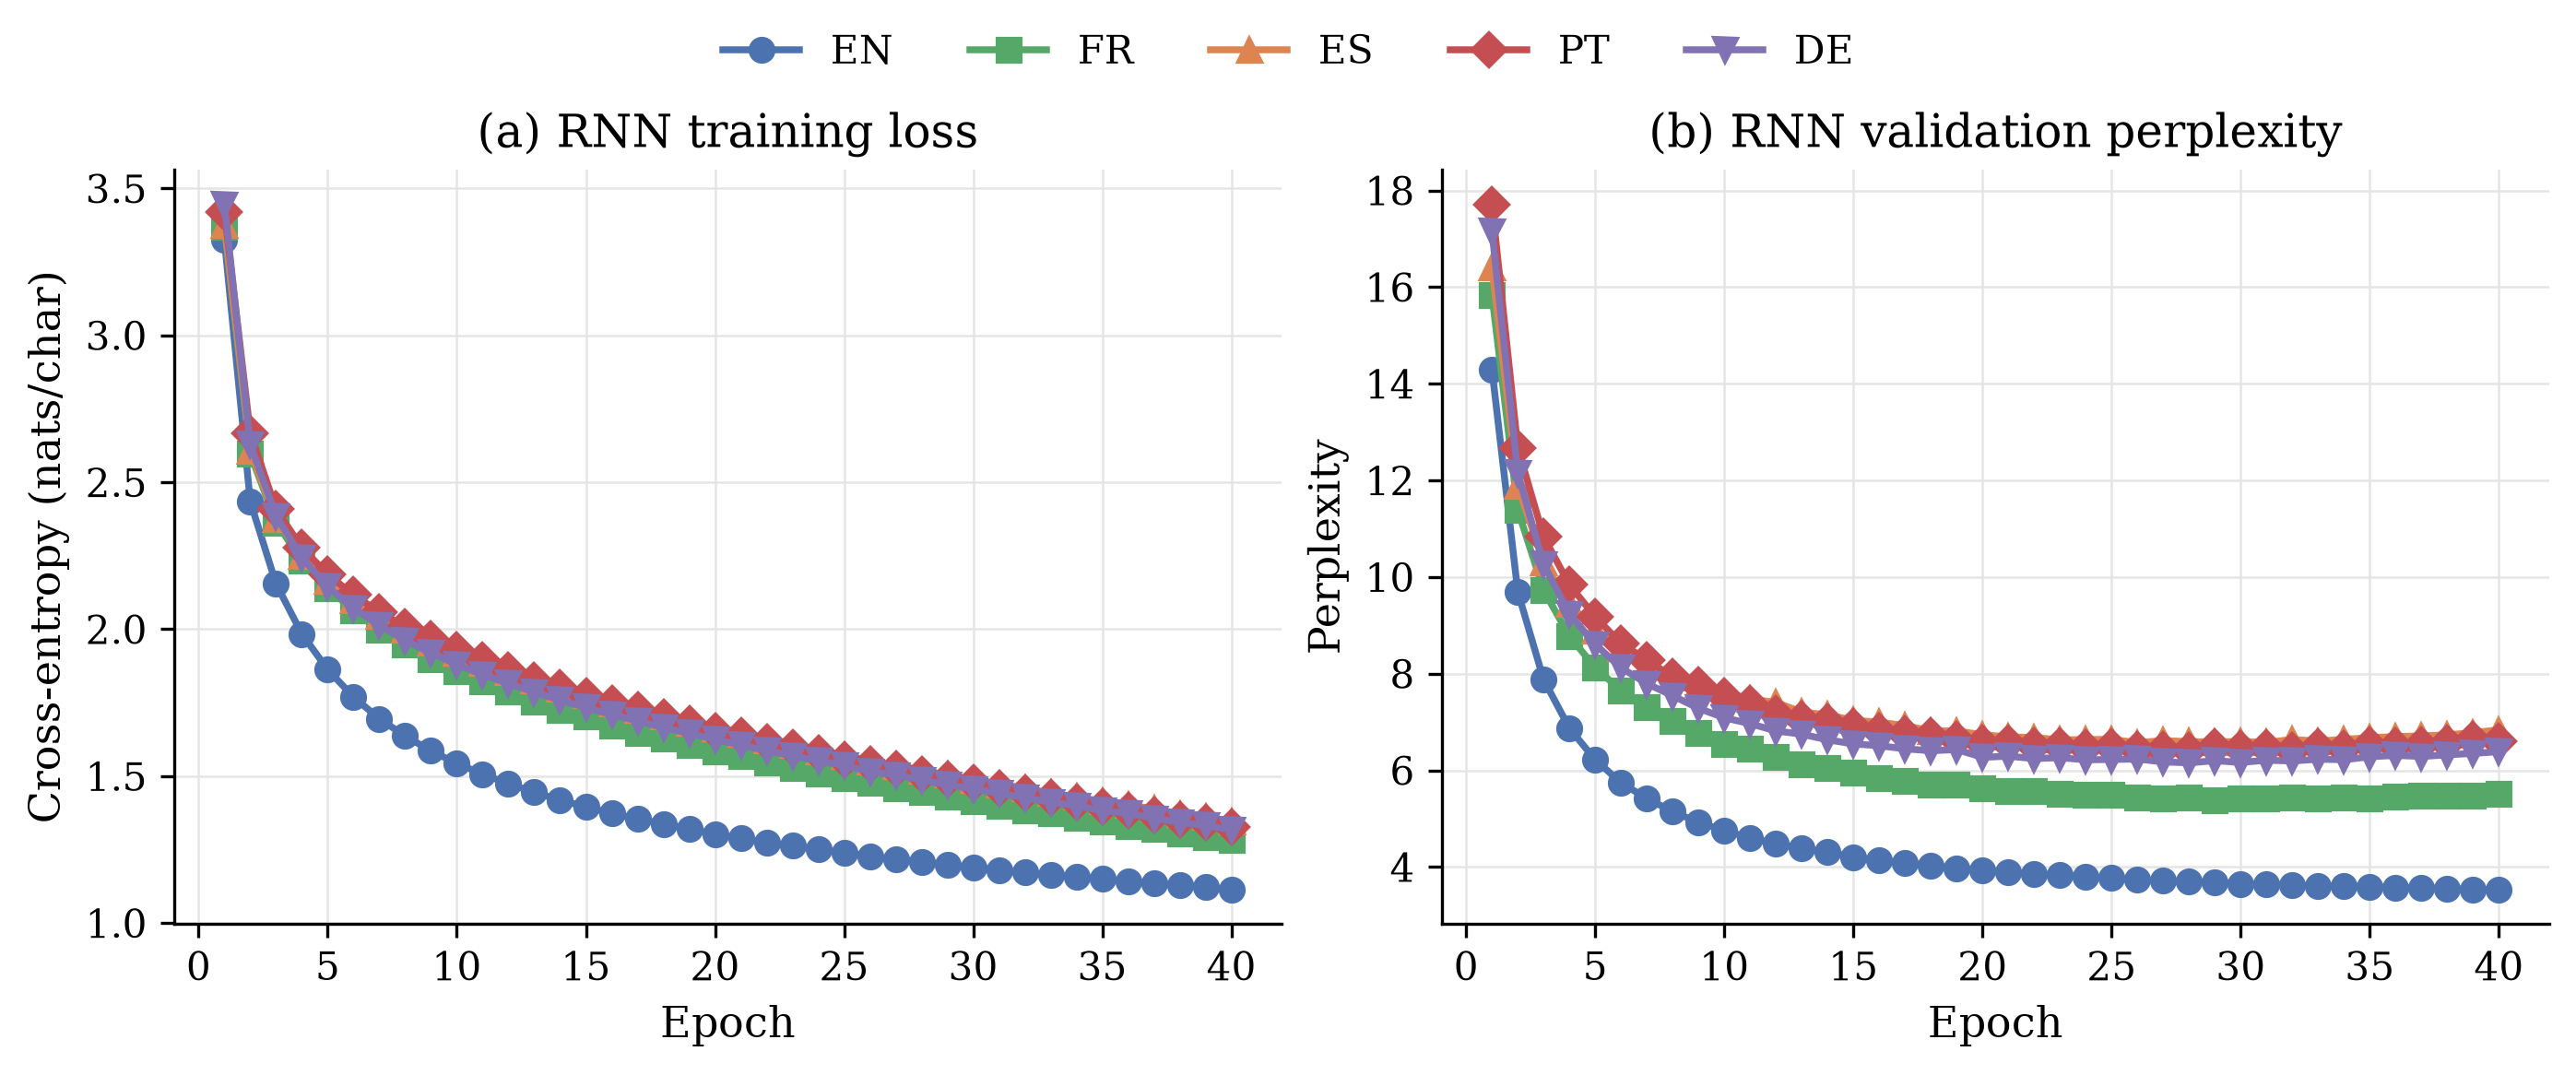

In [11]:
rnn_models, rnn_histories, rnn_train_cost = train_all_languages(
    cell="rnn",
    settings=SETTINGS,
    train_data=train_split,
    val_data=val_split,
    vocabulary=vocabulary,
    device=device,
)
plot_learning_curves(
    histories=rnn_histories,
    model_name="RNN",
    path=FIGURE_DIR / "rnn_learning_curves",
)

## ***2(b) Checkpoint Selection and Test Evaluation***

In [12]:
display(selection_table(histories=rnn_histories))
rnn_val, rnn_test, rnn_infer_cost = evaluate_neural(
    models=rnn_models,
    val_data=val_split,
    test_data=test_split,
    device=device,
)
display(summarize(evaluations={"RNN (validation)": rnn_val, "RNN (test)": rnn_test}))

,best_epoch,best_val_ppl
English,39.0,3.531634
French,29.0,5.390023
Spanish,26.0,6.571795
Portuguese,32.0,6.405349
German,28.0,6.156234


,accuracy,macro_f1,corpus_ppl
RNN (validation),0.985714,0.985673,4.618970
RNN (test),0.985714,0.985680,4.419887


## ***2(c) Confusion Matrix, Cost, and Prediction Analysis***

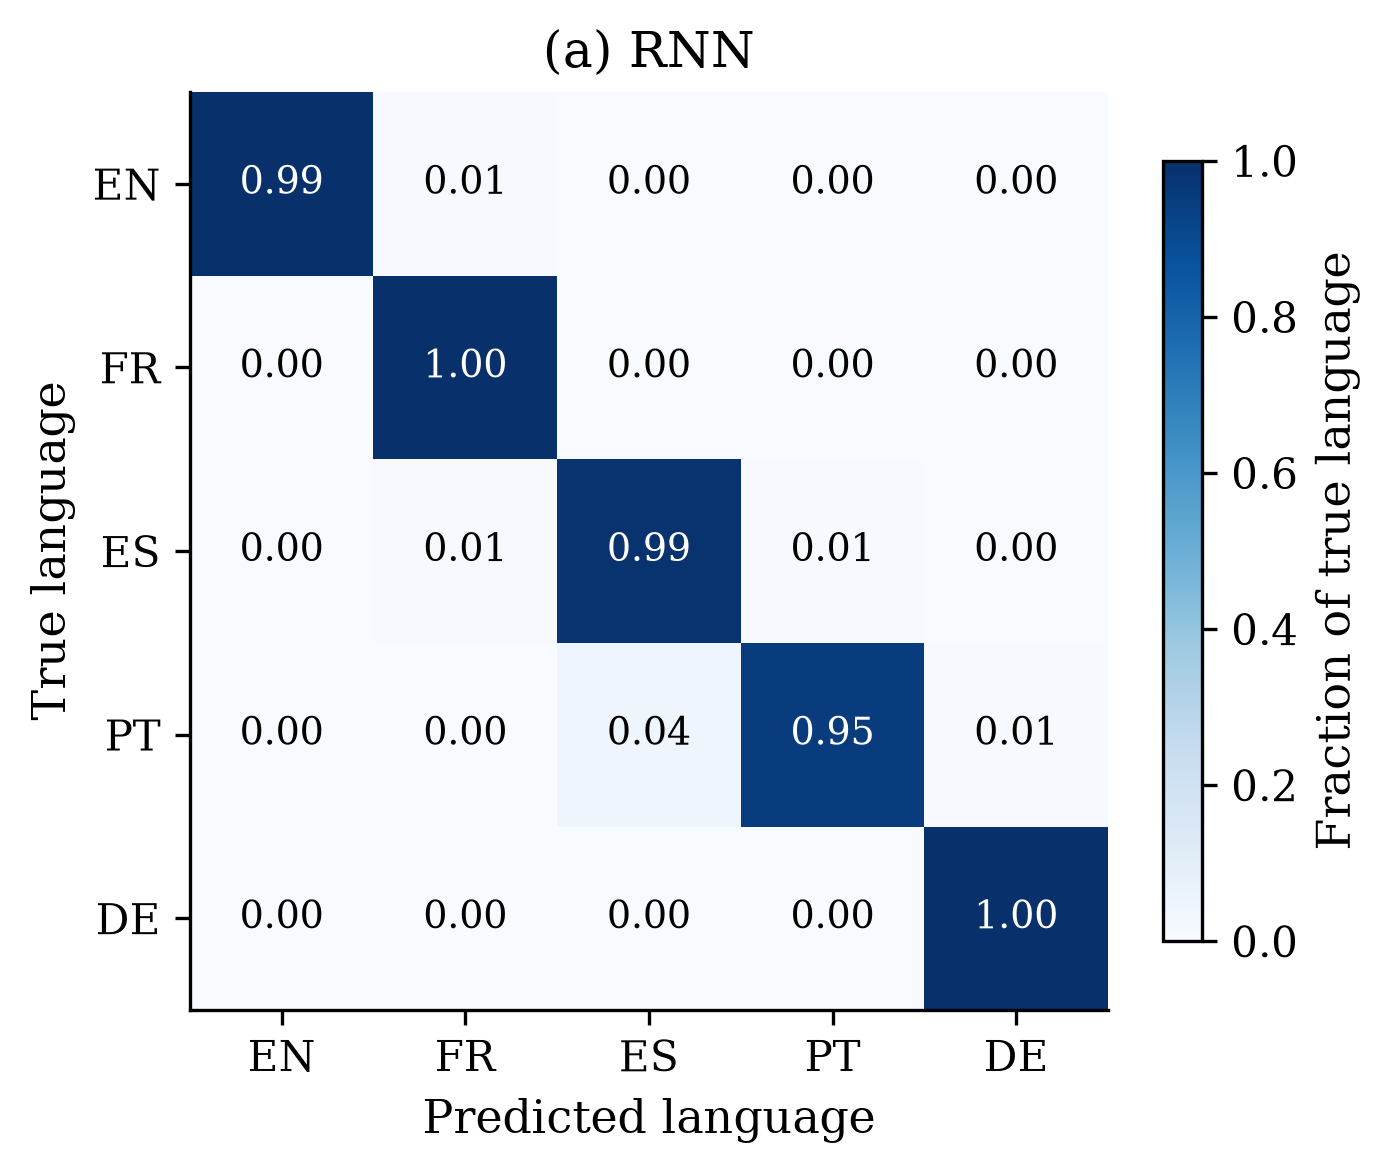

,RNN
training time (s),1155.346751
training peak GPU memory (MB),190.033691
inference time (s),1.358080
inference peak GPU memory (MB),144.019531


,errors
Spanish <-> Portuguese,7
English <-> French,1
Portuguese <-> German,1
French <-> Spanish,1
English <-> Spanish,0


,accuracy,count
Length,,
<=30,0.970732,205
31-60,0.987461,319
61-120,1.000000,90
>120,1.000000,86


,Text,Language,Predicted,Length,PPL_English,PPL_French,PPL_Spanish,PPL_Portuguese,PPL_German,Correct
292,para seis graus.,Portuguese,Portuguese,16,43.537412,15.845728,8.825086,7.053302,19.176469,True
520,"Doctores, trabajadores de la salud de 30 paíse...",Spanish,Spanish,59,60.994915,15.191548,4.645861,8.373304,42.961965,True
262,as intuições,Portuguese,Portuguese,12,206.708095,160.242411,124.380909,7.767233,158.791083,True
342,"moins serviable, moins à même de s'épanouir da...",French,French,71,124.386850,7.336313,51.663292,38.748539,79.243646,True
324,These are the verses of Allah which We recite ...,English,English,124,2.213406,45.127517,48.820921,60.374239,45.516291,True


,Text,Language,Predicted,Length,PPL_English,PPL_French,PPL_Spanish,PPL_Portuguese,PPL_German,Correct
214,4.800 --,Portuguese,German,8,628.143423,49.273559,35.488112,43.348526,25.549977,False
676,"Ándale! Ándale!""",Portuguese,Spanish,16,315.711826,181.719028,42.656576,184.304795,313.823698,False
72,o ritmo cardíaco sobe.,Portuguese,Spanish,22,67.598686,115.326539,19.158456,30.827600,115.948250,False
24,"""La tempestad"" en cine.",Spanish,French,23,42.546732,12.077944,14.118988,31.056423,56.761237,False
516,A cobertura jornalística,Portuguese,Spanish,24,80.641231,45.923106,16.417279,18.604434,123.407771,False
285,do que estou a falar. (Risos),Portuguese,Spanish,29,41.091958,40.275499,10.053375,10.383696,61.916131,False
386,grupos de gente feliz e infeliz,Spanish,Portuguese,31,75.611634,38.147135,17.250761,7.771357,34.126944,False
153,"de prevenir o desastre climático,",Portuguese,Spanish,33,26.802123,22.486629,7.290257,8.055589,65.209585,False
485,"Afinal, Jimmy Stewart obstruiu durante",Portuguese,Spanish,38,42.889653,22.057852,19.631905,25.804092,23.817773,False
32,across those 88 accordion-folded pages.,English,French,39,42.175328,28.714999,39.543154,84.661456,56.229260,False


In [13]:
plot_confusion_matrices(
    matrices={"RNN": rnn_test.confusion},
    path=FIGURE_DIR / "rnn_confusion_matrix",
)
display(
    cost_table(
        train_cost=rnn_train_cost,
        infer_cost=rnn_infer_cost,
    ).to_frame(name="RNN")
)
show_errors(
    evaluation=rnn_test,
    correct_examples=CORRECT_EXAMPLES,
)

**Discussion for 2(c)**

The RNN is written from scratch and unrolled over time step by step. With the suggested 10 epochs the validation perplexity was still decreasing, so I used val.csv to raise the budget to 40 epochs for both RNN and LSTM and kept the best checkpoint of each language. The RNN reaches 0.9857 accuracy and a test perplexity of 4.42, and its best epochs fall between 26 and 39, so it has roughly converged. Training takes 1155 s and 190 MB of GPU memory, mostly because the recurrence runs one character at a time in Python. It makes 10 mistakes, 7 of them between Spanish and Portuguese. Correct texts usually show a large gap, for example "as intuições" gets 7.8 under Portuguese and more than 120 under the other languages, while errors are near ties or noisy inputs such as "do que estou a falar. (Risos)" (10.05 for Spanish against 10.38 for Portuguese) or "4.800 --".


# ***3. LSTM***

## ***3(a) Training Loss and Validation Perplexity Curves***

LSTM English |██████████| 100% 40/40 [35:03<00:00, loss 1.313, val PPL 4.021]
LSTM French |██████████| 100% 40/40 [06:39<00:00, loss 1.624, val PPL 5.870]
LSTM Spanish |██████████| 100% 40/40 [05:14<00:00, loss 1.671, val PPL 7.006] 
LSTM Portuguese |██████████| 100% 40/40 [05:26<00:00, loss 1.624, val PPL 6.897] 
LSTM German |██████████| 100% 40/40 [05:25<00:00, loss 1.601, val PPL 6.545]


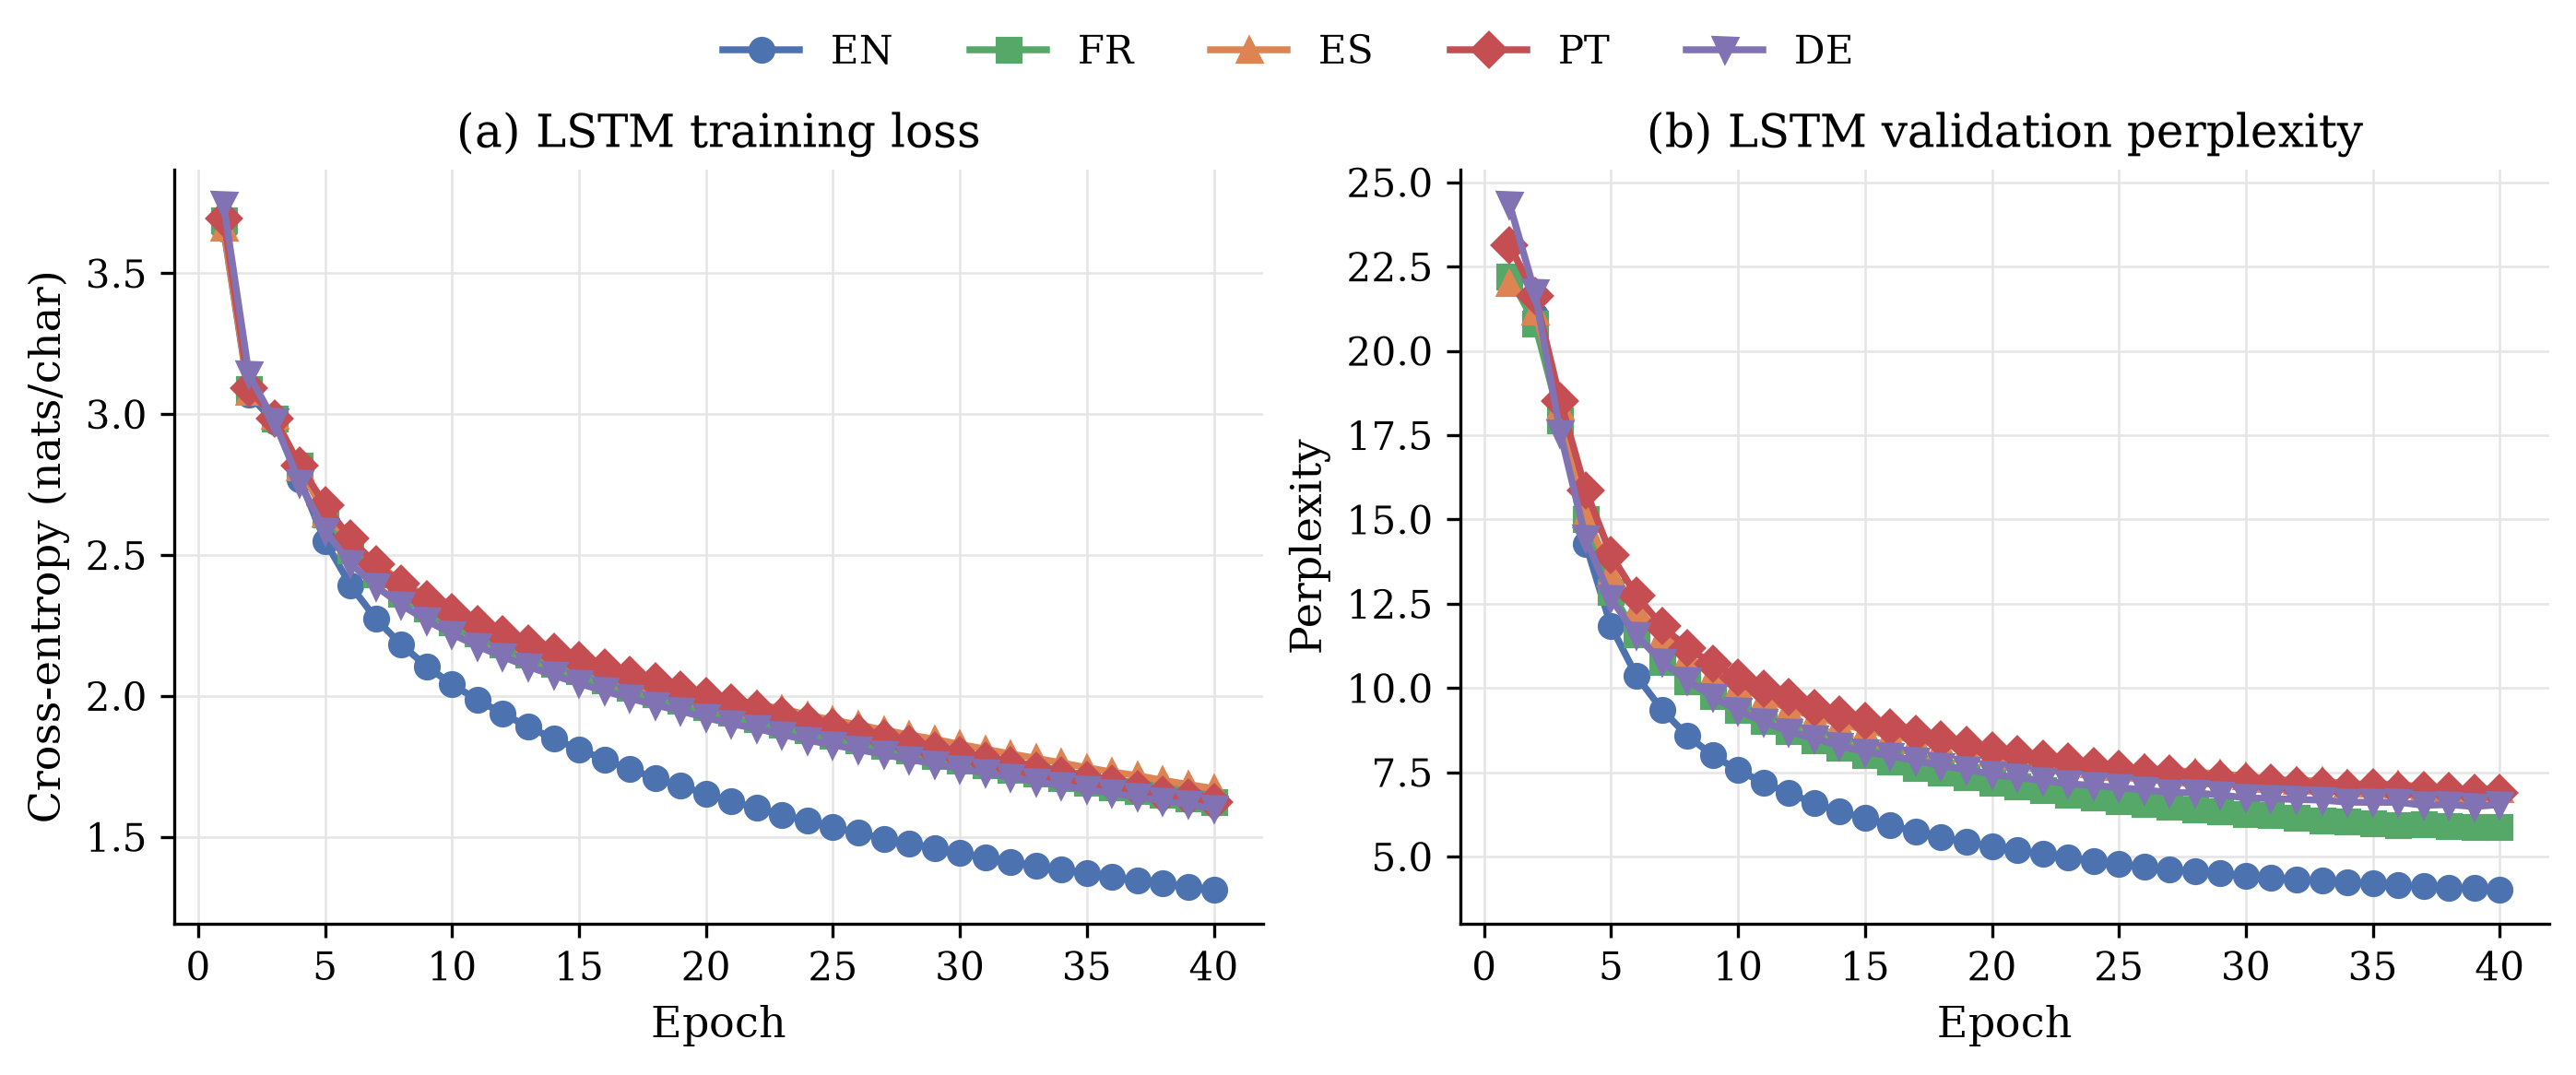

In [14]:
lstm_models, lstm_histories, lstm_train_cost = train_all_languages(
    cell="lstm",
    settings=SETTINGS,
    train_data=train_split,
    val_data=val_split,
    vocabulary=vocabulary,
    device=device,
)
plot_learning_curves(
    histories=lstm_histories,
    model_name="LSTM",
    path=FIGURE_DIR / "lstm_learning_curves",
)

## ***3(b) Checkpoint Selection and Test Evaluation***

In [15]:
display(selection_table(histories=lstm_histories))
lstm_val, lstm_test, lstm_infer_cost = evaluate_neural(
    models=lstm_models,
    val_data=val_split,
    test_data=test_split,
    device=device,
)
display(summarize(evaluations={"LSTM (validation)": lstm_val, "LSTM (test)": lstm_test}))

,best_epoch,best_val_ppl
English,40.0,4.021441
French,40.0,5.869522
Spanish,39.0,6.986489
Portuguese,40.0,6.897432
German,39.0,6.486030


,accuracy,macro_f1,corpus_ppl
LSTM (validation),0.985714,0.985680,5.101782
LSTM (test),0.984286,0.984232,4.914909


## ***3(c) Confusion Matrix, Cost, and Prediction Analysis***

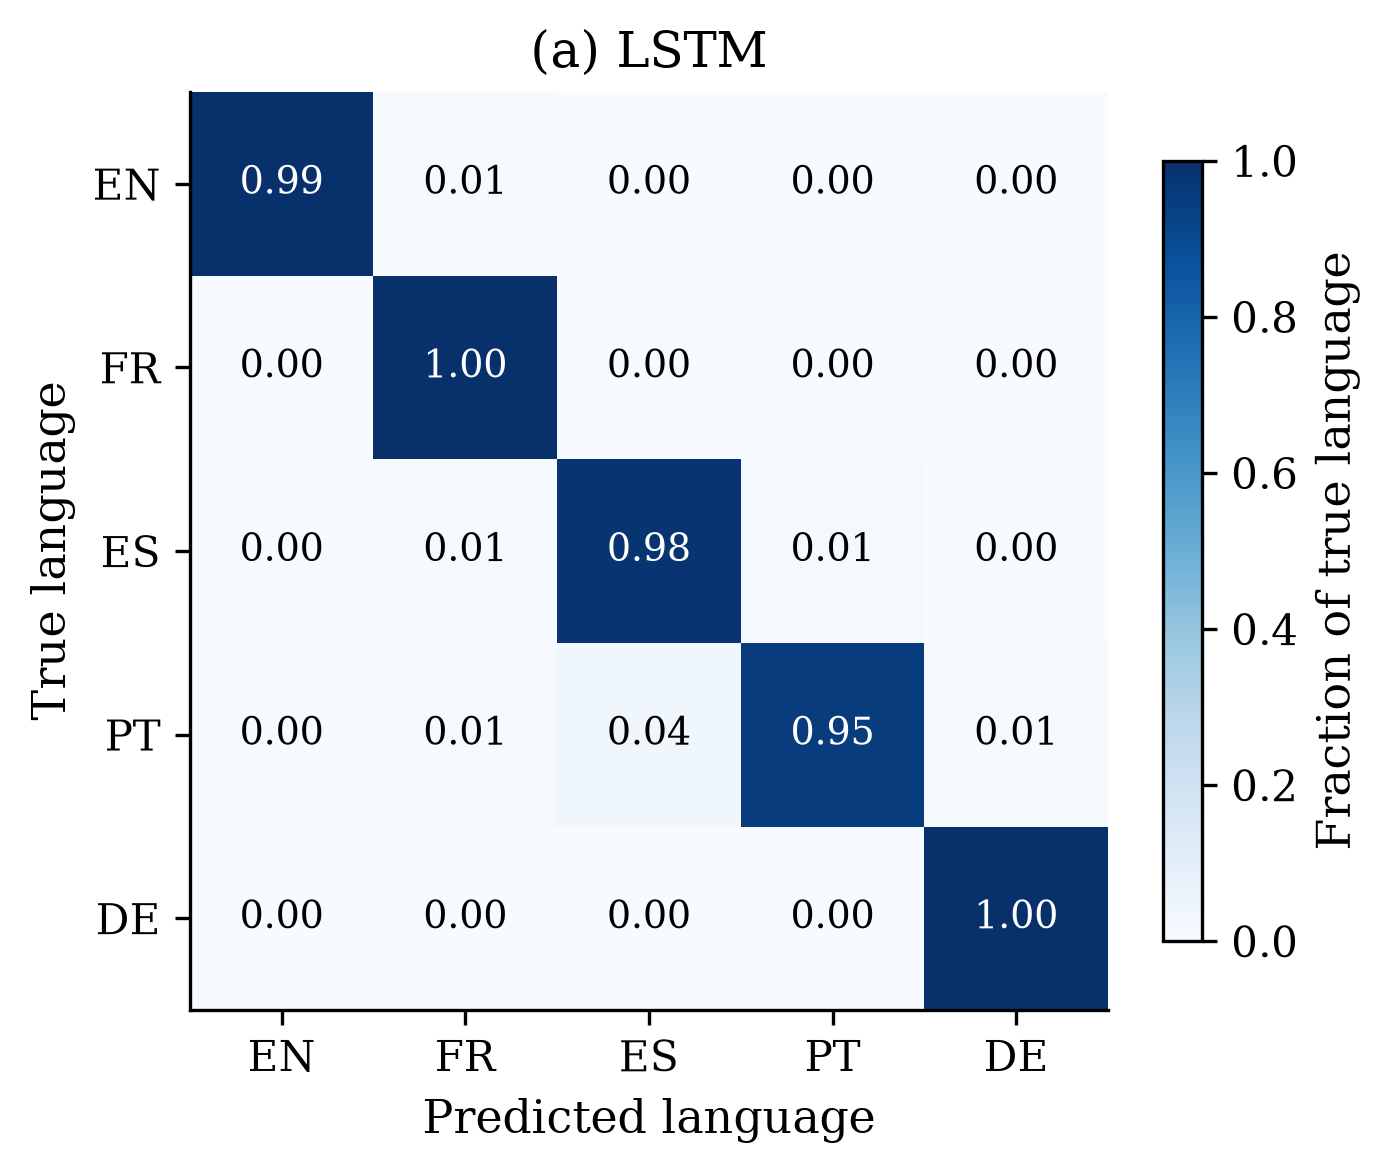

,LSTM
training time (s),3470.295539
training peak GPU memory (MB),632.121582
inference time (s),3.212159
inference peak GPU memory (MB),300.416016


,errors
Spanish <-> Portuguese,7
English <-> French,1
Portuguese <-> German,1
French <-> Portuguese,1
French <-> Spanish,1


,accuracy,count
Length,,
<=30,0.975610,205
31-60,0.981191,319
61-120,1.000000,90
>120,1.000000,86


,Text,Language,Predicted,Length,PPL_English,PPL_French,PPL_Spanish,PPL_Portuguese,PPL_German,Correct
291,"sur le lac de Neuchâtel, près de Genève.",French,French,40,156.635579,11.639678,47.571258,39.875585,61.209869,True
665,qui nous fait sauter au plafond.,French,French,32,25.272414,4.883224,23.762800,19.000977,27.932057,True
262,as intuições,Portuguese,Portuguese,12,167.032551,66.246378,161.294897,7.018500,232.304931,True
341,For each [religious following] is a direction ...,English,English,221,3.629465,41.388813,44.673118,59.347959,33.829908,True
323,la forma de arte de mayor influencia en el sig...,Spanish,Spanish,52,63.411081,15.114238,8.000881,19.772124,44.081826,True


,Text,Language,Predicted,Length,PPL_English,PPL_French,PPL_Spanish,PPL_Portuguese,PPL_German,Correct
214,4.800 --,Portuguese,German,8,486.521183,75.691421,61.627054,74.168826,37.706080,False
467,"Decidimos,",Portuguese,Spanish,10,31.898747,47.206997,9.653672,11.537578,47.681554,False
676,"Ándale! Ándale!""",Portuguese,Spanish,16,223.239328,216.412152,56.697293,183.091015,302.735688,False
72,o ritmo cardíaco sobe.,Portuguese,Spanish,22,73.246651,78.148542,17.035425,22.562836,120.151089,False
24,"""La tempestad"" en cine.",Spanish,French,23,30.138623,10.981656,14.636374,21.664088,33.096109,False
386,grupos de gente feliz e infeliz,Spanish,Portuguese,31,40.099670,24.775011,15.947642,7.814757,33.339900,False
597,de forma bastante depreciativa.,Portuguese,Spanish,31,22.040106,12.088960,5.749718,5.882242,26.374767,False
492,"Eso está mal, completamente mal.",Spanish,Portuguese,32,30.270205,26.237495,6.268875,6.171876,21.144265,False
147,de correr descalça em Table Mountain e,Portuguese,French,38,51.373844,18.803674,29.803503,19.845441,54.092062,False
485,"Afinal, Jimmy Stewart obstruiu durante",Portuguese,Spanish,38,28.901660,25.284317,21.966553,34.351462,22.448141,False


In [16]:
plot_confusion_matrices(
    matrices={"LSTM": lstm_test.confusion},
    path=FIGURE_DIR / "lstm_confusion_matrix",
)
display(
    cost_table(
        train_cost=lstm_train_cost,
        infer_cost=lstm_infer_cost,
    ).to_frame(name="LSTM")
)
show_errors(
    evaluation=lstm_test,
    correct_examples=CORRECT_EXAMPLES,
)

**Discussion for 3(c)**

The LSTM is also written from scratch, with its four gates and cell state computed at every step. It reaches 0.9843 accuracy and a test perplexity of 4.91, slightly behind the RNN. Its best epochs are 39 and 40, so unlike the RNN it is still improving at the end of training, which suggests it needs even more updates because of its larger number of parameters (1.49 M against 0.50 M). Training is the most expensive of all models, 3470 s and 632 MB, about three times the RNN. It makes 11 mistakes, again mostly Spanish and Portuguese near ties like "Eso está mal, completamente mal." (6.17 for Portuguese against 6.27 for Spanish), and it is the best model on texts of at most 30 characters with 0.976 accuracy.


# ***4. Comparison of Bigram, Trigram, RNN, and LSTM***

In [17]:
def count_parameters(*, models: Mapping[str, nn.Module]) -> int:
    return sum(parameter.numel() for model in models.values() for parameter in model.parameters())


all_val = {**ngram_val, "RNN": rnn_val, "LSTM": lstm_val}
all_test = {**ngram_test, "RNN": rnn_test, "LSTM": lstm_test}
all_costs = {
    **{name: (build_costs[name], infer_costs[name], "CPU") for name in ngram_models},
    "RNN": (rnn_train_cost, rnn_infer_cost, "GPU"),
    "LSTM": (lstm_train_cost, lstm_infer_cost, "GPU"),
}
model_sizes = {
    **{name: sum(model.stored_counts for model in models.values()) for name, models in ngram_models.items()},
    "RNN": count_parameters(models=rnn_models),
    "LSTM": count_parameters(models=lstm_models),
}

display(
    pd.DataFrame(
        data={
            name: {
                "hardware": hardware,
                "stored counts / parameters": model_sizes[name],
                "train/build time (s)": train_cost.seconds,
                "train/build peak memory (MB)": train_cost.peak_mb,
                "inference time (s)": infer_cost.seconds,
                "inference peak memory (MB)": infer_cost.peak_mb,
                "val corpus PPL": all_val[name].corpus_ppl,
                "test corpus PPL": all_test[name].corpus_ppl,
                "test accuracy": all_test[name].accuracy,
                "test macro-F1": all_test[name].macro_f1,
            }
            for name, (train_cost, infer_cost, hardware) in all_costs.items()
        }
    ).T
)

,hardware,stored counts / parameters,train/build time (s),train/build peak memory (MB),inference time (s),inference peak memory (MB),val corpus PPL,test corpus PPL,test accuracy,test macro-F1
Bigram,CPU,5855,1.055965,0.468047,0.806123,0.05848,11.437324,11.326449,0.972857,0.972714
Trigram,CPU,30307,0.942103,2.852859,0.78047,0.071037,9.700802,9.402167,0.987143,0.987075
RNN,GPU,496005,1155.346751,190.033691,1.35808,144.019531,4.61897,4.419887,0.985714,0.98568
LSTM,GPU,1486725,3470.295539,632.121582,3.212159,300.416016,5.101782,4.914909,0.984286,0.984232


## ***4.1 Perplexity versus Identification Accuracy***

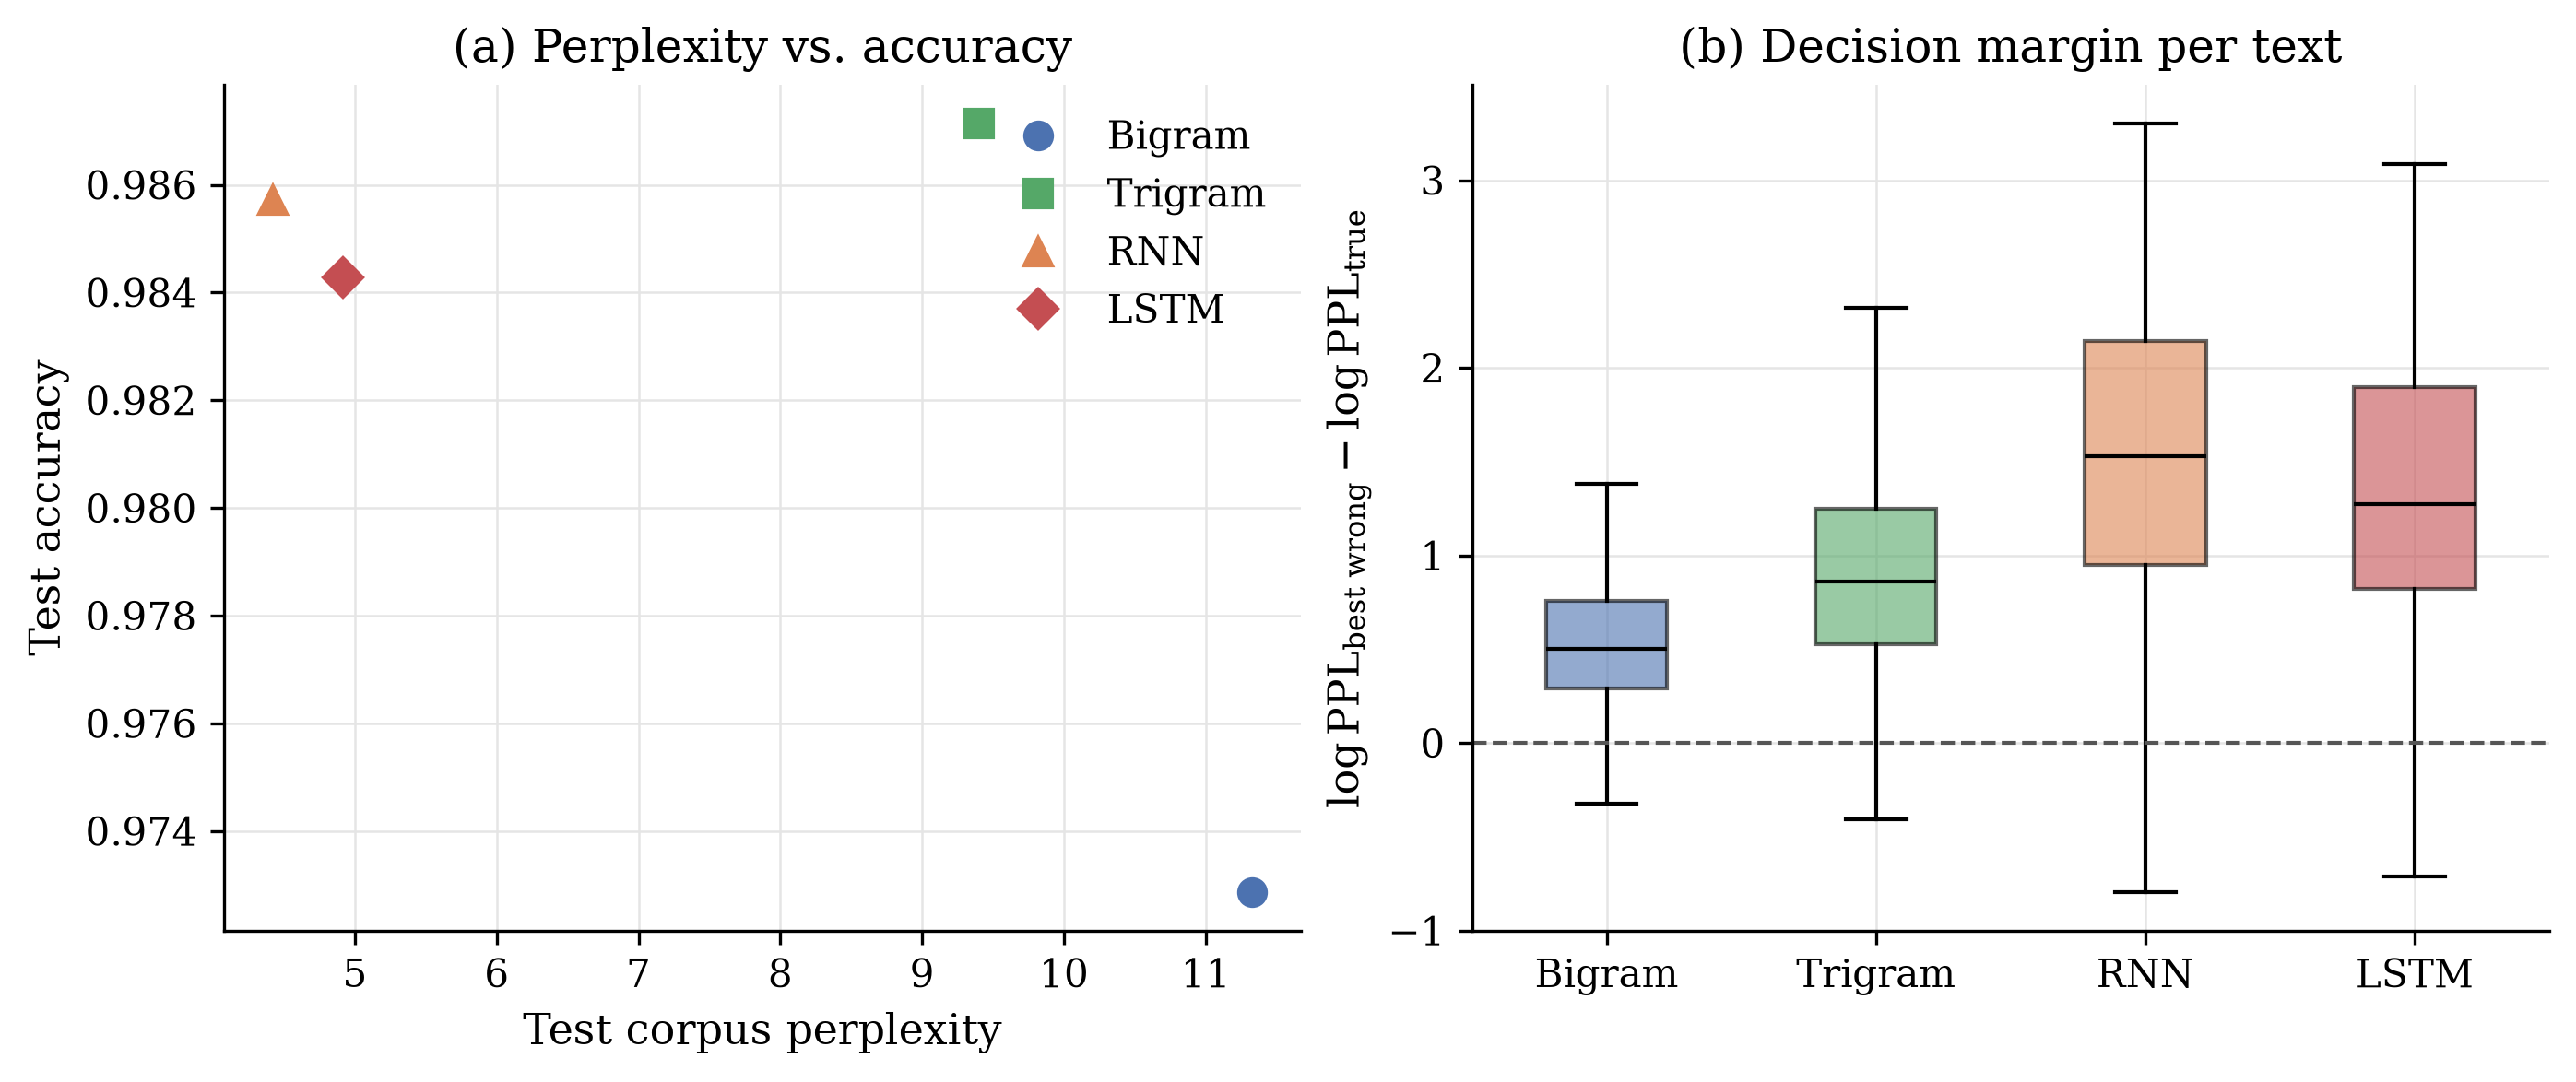

,accuracy,macro_f1,corpus_ppl,median_margin
Bigram,0.972857,0.972714,11.326449,0.502953
Trigram,0.987143,0.987075,9.402167,0.860689
RNN,0.985714,0.985680,4.419887,1.527280
LSTM,0.984286,0.984232,4.914909,1.272899


In [18]:
def decision_margins(*, table: pd.DataFrame) -> np.ndarray:
    log_ppl = np.log(table[[f"PPL_{language}" for language in LANGUAGES]].to_numpy())
    is_true = np.eye(
        len(LANGUAGES),
        dtype=bool,
    )[[LANGUAGES.index(language) for language in table["Language"]]]
    return np.where(is_true, np.inf, log_ppl).min(axis=1) - log_ppl[is_true]


def plot_perplexity_vs_accuracy(
    *,
    evaluations: Mapping[str, Evaluation],
    margins: Mapping[str, np.ndarray],
    path: Path,
) -> None:
    width, height = PANEL_SIZE
    figure, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(2 * width, height),
        constrained_layout=True,
    )
    for name, evaluation in evaluations.items():
        axes[0].plot(
            evaluation.corpus_ppl,
            evaluation.accuracy,
            linestyle="none",
            markersize=7,
            label=name,
            **MODEL_STYLES[name],
        )
    axes[0].set(
        title=panel_title(
            index=0,
            title="Perplexity vs. accuracy",
        ),
        xlabel="Test corpus perplexity",
        ylabel="Test accuracy",
    )
    axes[0].legend(loc="best")
    boxes = axes[1].boxplot(
        x=list(margins.values()),
        tick_labels=list(margins),
        patch_artist=True,
        showfliers=False,
        medianprops={"color": "black"},
    )
    for box, name in zip(boxes["boxes"], margins):
        box.set(
            facecolor=MODEL_STYLES[name]["color"],
            alpha=0.6,
        )
    axes[1].axhline(
        y=0,
        color="#555555",
        linestyle="--",
        linewidth=1,
    )
    axes[1].set(
        title=panel_title(
            index=1,
            title="Decision margin per text",
        ),
        ylabel=r"$\log \mathrm{PPL}_{\mathrm{best\ wrong}} - \log \mathrm{PPL}_{\mathrm{true}}$",
    )
    save_figure(
        figure=figure,
        path=path,
    )
    plt.show()


margins = {name: decision_margins(table=evaluation.table) for name, evaluation in all_test.items()}
plot_perplexity_vs_accuracy(
    evaluations=all_test,
    margins=margins,
    path=FIGURE_DIR / "comparison_perplexity_accuracy",
)
median_margins = {name: float(np.median(margin)) for name, margin in margins.items()}
display(summarize(evaluations=all_test).assign(median_margin=median_margins))

## ***4.2 Most Frequently Confused Language Pairs***

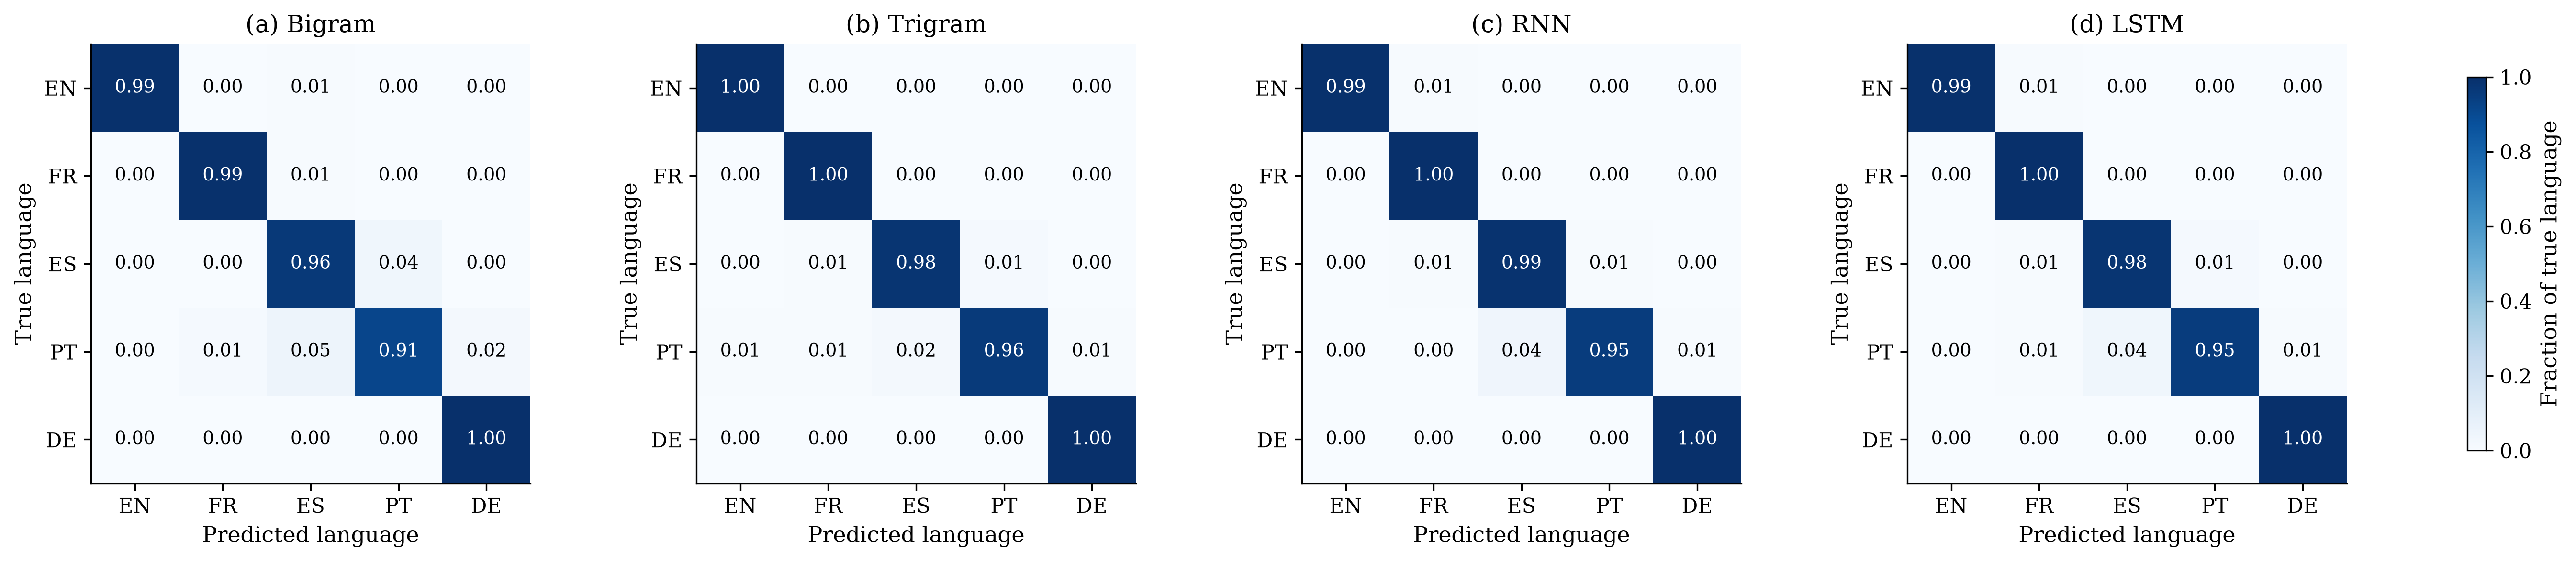

,Bigram,Trigram,RNN,LSTM,total
Spanish <-> Portuguese,12,5,7,7,31
Portuguese <-> German,3,1,1,1,6
French <-> Portuguese,2,1,0,1,4
French <-> Spanish,1,1,1,1,4
English <-> French,0,0,1,1,2
English <-> Spanish,1,0,0,0,1
English <-> Portuguese,0,1,0,0,1
English <-> German,0,0,0,0,0
French <-> German,0,0,0,0,0
Spanish <-> German,0,0,0,0,0


In [19]:
plot_confusion_matrices(
    matrices={name: evaluation.confusion for name, evaluation in all_test.items()},
    path=FIGURE_DIR / "comparison_confusion_matrices",
)
pair_table = pd.concat(
    objs={name: confused_pairs(matrix=evaluation.confusion)["errors"] for name, evaluation in all_test.items()},
    axis=1,
)
display(
    pair_table.assign(total=pair_table.sum(axis=1)).sort_values(
        by="total",
        ascending=False,
    )
)

## ***4.3 Effect of Text Length***

,Bigram,Trigram,RNN,LSTM,count
Length,,,,,
<=30,0.941463,0.970732,0.970732,0.975610,205
31-60,0.981191,0.990596,0.987461,0.981191,319
61-120,0.988889,1.000000,1.000000,1.000000,90
>120,1.000000,1.000000,1.000000,1.000000,86


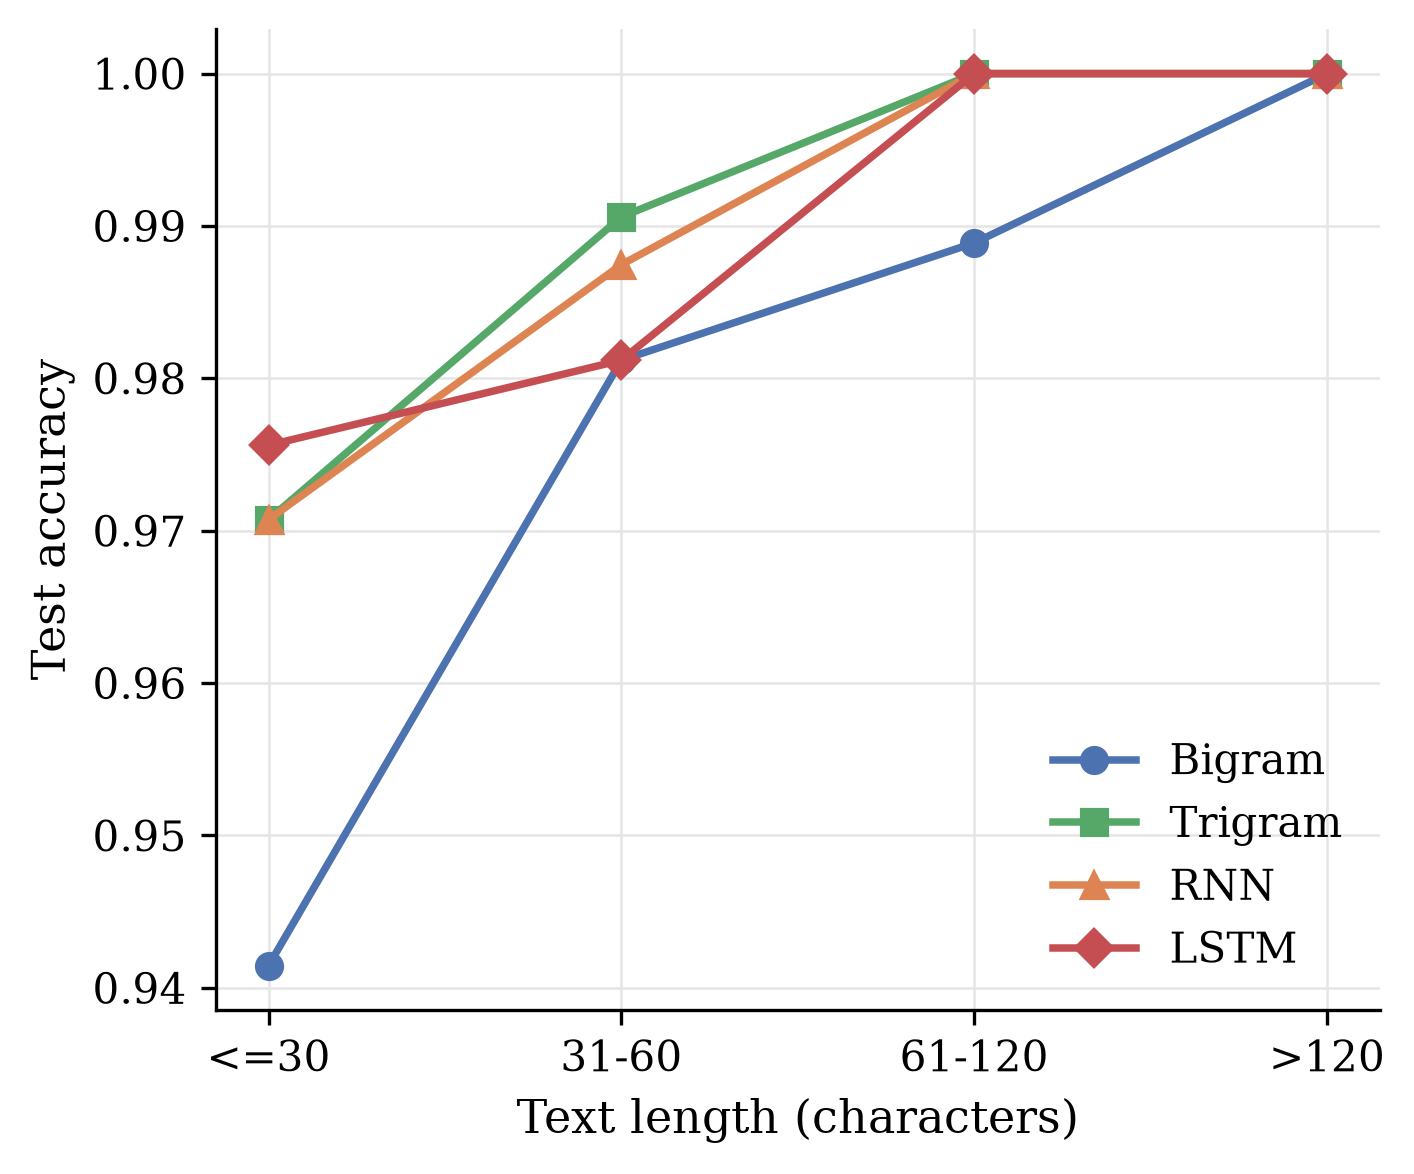

In [20]:
def plot_accuracy_by_length(
    *,
    length_table: pd.DataFrame,
    path: Path,
) -> None:
    figure, ax = plt.subplots(
        figsize=PANEL_SIZE,
        constrained_layout=True,
    )
    for name in length_table.columns:
        ax.plot(
            length_table.index.astype(str),
            length_table[name],
            label=name,
            **MODEL_STYLES[name],
        )
    ax.set(
        xlabel="Text length (characters)",
        ylabel="Test accuracy",
    )
    ax.legend(loc="lower right")
    save_figure(
        figure=figure,
        path=path,
    )
    plt.show()


length_table = pd.concat(
    objs={name: accuracy_by_length(table=evaluation.table)["accuracy"] for name, evaluation in all_test.items()},
    axis=1,
)
display(length_table.assign(count=accuracy_by_length(table=all_test["Bigram"].table)["count"]))
plot_accuracy_by_length(
    length_table=length_table,
    path=FIGURE_DIR / "comparison_accuracy_by_length",
)

## ***4.4 Per-Language Test Accuracy***

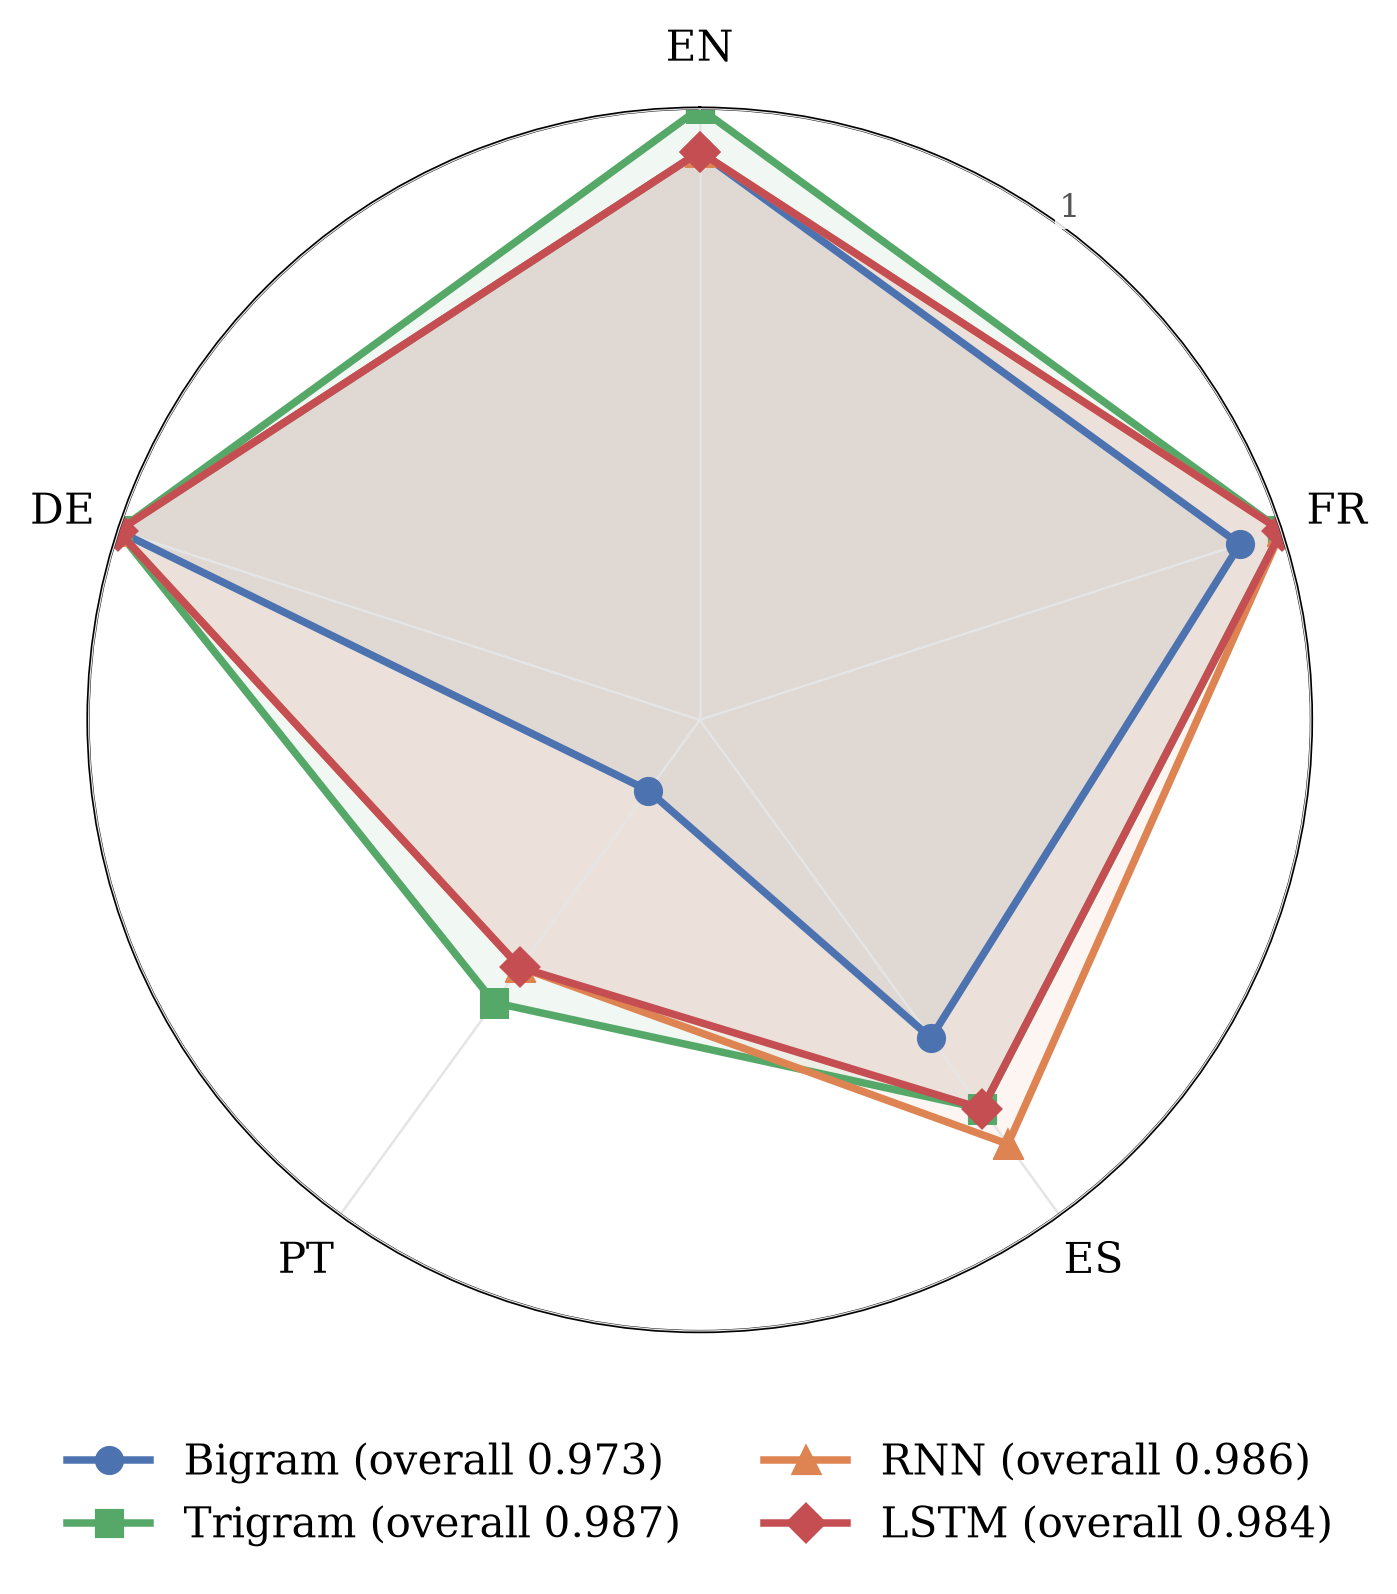

In [21]:
RADAR_SIZE = (5.2, 5.2)
RADAR_FILL_ALPHA = 0.08
RADAR_FLOOR_STEP = 0.1
RADAR_LABEL_ANGLE = 36
RADAR_LABEL_ZORDER = 10


def per_language_accuracy(*, evaluation: Evaluation) -> np.ndarray:
    return np.diag(evaluation.confusion) / np.maximum(evaluation.confusion.sum(axis=1), 1)


def plot_language_radar(
    *,
    accuracies: Mapping[str, np.ndarray],
    overall: Mapping[str, float],
    path: Path,
) -> None:
    angles = np.linspace(
        start=0.0,
        stop=2 * np.pi,
        num=len(LANGUAGES),
        endpoint=False,
    )
    closed_angles = np.append(angles, angles[0])
    floor = math.floor(min(values.min() for values in accuracies.values()) / RADAR_FLOOR_STEP) * RADAR_FLOOR_STEP

    figure, ax = plt.subplots(
        figsize=RADAR_SIZE,
        subplot_kw={"projection": "polar"},
        constrained_layout=True,
    )
    for model, values in accuracies.items():
        closed_values = np.append(values, values[0])
        ax.plot(
            closed_angles,
            closed_values,
            label=f"{model} (overall {overall[model]:.3f})",
            **MODEL_STYLES[model],
        )
        ax.fill(
            closed_angles,
            closed_values,
            color=MODEL_STYLES[model]["color"],
            alpha=RADAR_FILL_ALPHA,
        )
    ax.set_xticks(
        ticks=angles,
        labels=[LANGUAGE_CODES[language] for language in LANGUAGES],
    )
    ax.set_theta_offset(offset=np.pi / 2)
    ax.set_theta_direction(direction=-1)
    ax.set_ylim(
        bottom=floor,
        top=1.0,
    )
    ax.set_yticks(
        ticks=np.arange(
            start=floor,
            stop=1.0 + EPSILON,
            step=RADAR_FLOOR_STEP,
        )
    )
    ax.set_rlabel_position(value=RADAR_LABEL_ANGLE)
    ax.tick_params(
        axis="y",
        labelsize=8,
        labelcolor="#555555",
    )
    ax.yaxis.set_zorder(level=RADAR_LABEL_ZORDER)
    for tick_label in ax.get_yticklabels():
        tick_label.set_bbox({"facecolor": "white", "edgecolor": "none", "alpha": 0.85, "pad": 1})
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.06),
        ncols=2,
    )
    save_figure(
        figure=figure,
        path=path,
    )
    plt.show()


plot_language_radar(
    accuracies={name: per_language_accuracy(evaluation=evaluation) for name, evaluation in all_test.items()},
    overall={name: evaluation.accuracy for name, evaluation in all_test.items()},
    path=FIGURE_DIR / "comparison_language_radar",
)

**Discussion for 4**

The n-gram models need only a CPU, about one second of training and a few MB of memory, while the RNN and LSTM need a GPU, 19 to 58 minutes of training and up to 0.63 GB, and are slower at inference (1.4 to 3.2 s against 0.8 s). The trigram is the most accurate model (0.9871), followed by the RNN (0.9857), the LSTM (0.9843) and the bigram (0.9729), with the same order for Macro-F1. Lower perplexity therefore does not guarantee higher accuracy, since the RNN and LSTM have less than half the perplexity of the trigram (4.42 and 4.91 against 9.40) but still misclassify a few more texts, because identification depends on the gap to the best wrong language on ambiguous texts rather than on how well the true model predicts its own text. Spanish and Portuguese are the most confused pair for every model (31 of the 49 errors), and all models get worse on short texts, dropping from perfect accuracy above 120 characters to between 0.941 and 0.976 at 30 characters or less.
